<h1 style="color:teal;">Exploración Inicial del Dataset 01 N-CMAPSS</h1>
<p> Valentina Arce España <p>
<p> Febrero 03, 2026 <p>
<p> Este set se enfoca en fallas de eficiencia de la turbina de alta presión.<p>

## Archivos HDF5

HDF5 significa Hierarchical Data Format version 5. Se piensa como un sistema de archivos (como una mini computadora) dentro de un solo archivo. 

1. La analogía del "Archivador"
Si un archivo .csv es una hoja de papel suelta, un archivo .h5 es un mueble archivador con cajones, carpetas y etiquetas.

    * Grupos (Groups): Son como las "carpetas". Pueden contener otras carpetas o archivos.

    * Datasets: Son los "archivos" reales (las matrices de números). En tu caso, X_s_dev, W_dev, etc., son datasets.

    * Atributos (Attributes): Son "metadatos" o notas adhesivas pegadas a las carpetas. Pueden decir quién creó el archivo, en qué unidades están los sensores, etc.

2. ¿Por qué la NASA usa H5 y no CSV o Excel?
El N-CMAPSS tiene millones de filas. Si intentaras abrir eso en Excel, tu computadora probablemente se bloquearía. El H5 tiene tres ventajas críticas para ingeniería:

    * Acceso Aleatorio (Carga Selectiva): No necesitas cargar los 5GB de datos en la RAM para ver solo una columna. Puedes decirle a Python: "Solo léeme la columna 5 del dataset X_s_dev", y lo hará sin leer el resto.

    * Compresión: El formato guarda los números de forma binaria, lo que ocupa mucho menos espacio que el texto.

    * Estructura Jerárquica: Permite guardar en un solo lugar los datos de los sensores, los nombres de las columnas (_var) y la información de las unidades (A_dev) de forma organizada.

4. ¿Qué es lo que se verá en VS Code?
Cuando se cargue X_s_var, se va al cajón de "etiquetas". Cuando se cargue X_s_dev, se va al cajón de "números". Al unirlos en un DataFrame de Pandas, lo que se hace es pegar las etiquetas sobre los números para que sean legibles para nosotros los humanos.

<h2 style="color:teal;">Carga de Datos</h2>

#### Paso 1: Configuración inicial y lectura de claves
Lo primero es abrir el archivo y listar las "llaves" (keys). Las llaves son como carpetas dentro del archivo.

* Explicación de Dev vs Test:

    *  _dev (Development): Son los datos de entrenamiento. Contienen trayectorias completas de "run-to-failure" (desde que el motor está sano hasta que falla). Aquí es donde entrenas tus modelos.

    * _test (Test): Son datos para probar el modelo. En N-CMAPSS, a menudo también son trayectorias completas, pero se usan para verificar qué tan bien generaliza tu modelo en motores que nunca ha visto.

In [1]:
import h5py
import numpy as np
import pandas as pd

# Asegúrate de que el nombre del archivo coincida con el que descargaste (DS01)
filename = 'N-CMAPSS_DS01-005.h5' 

# 1. Abrir el archivo en modo lectura ('r')
with h5py.File(filename, 'r') as hdf:
    # Listar todas las llaves principales para ver qué hay dentro
    print("Llaves principales en el archivo HDF5:")
    print(list(hdf.keys()))

Llaves principales en el archivo HDF5:
['A_dev', 'A_test', 'A_var', 'T_dev', 'T_test', 'T_var', 'W_dev', 'W_test', 'W_var', 'X_s_dev', 'X_s_test', 'X_s_var', 'X_v_dev', 'X_v_test', 'X_v_var', 'Y_dev', 'Y_test']


#### Paso 2: Cargar los Nombres de las Variables (Columnas)
Antes de cargar los millones de datos, carguemos los nombres de las columnas para saber qué estamos viendo. El archivo .h5 tiene variables auxiliares que terminan en _var que contienen estos nombres. **Los resultados a continuación coinciden con el Paper.**

In [2]:
with h5py.File(filename, 'r') as hdf:
    # Cargar nombres de variables (decodificamos de bytes a strings para leerlos bien)
    w_cols = np.array(hdf.get('W_var')).astype(str)   # Condiciones Operativas
    x_s_cols = np.array(hdf.get('X_s_var')).astype(str) # Sensores Físicos
    x_v_cols = np.array(hdf.get('X_v_var')).astype(str) # Sensores Virtuales
    t_cols = np.array(hdf.get('T_var')).astype(str)   # Theta (Salud del motor)
    a_cols = np.array(hdf.get('A_var')).astype(str)   # Información Auxiliar

    print("Columnas W (Operativas):", w_cols)
    print("Columnas X_s (Sensores):", x_s_cols)
    print("Columnas T (Theta/Salud):", t_cols)
    print("Columnas A (Auxiliares):", a_cols)

Columnas W (Operativas): ['alt' 'Mach' 'TRA' 'T2']
Columnas X_s (Sensores): ['T24' 'T30' 'T48' 'T50' 'P15' 'P2' 'P21' 'P24' 'Ps30' 'P40' 'P50' 'Nf'
 'Nc' 'Wf']
Columnas T (Theta/Salud): ['fan_eff_mod' 'fan_flow_mod' 'LPC_eff_mod' 'LPC_flow_mod' 'HPC_eff_mod'
 'HPC_flow_mod' 'HPT_eff_mod' 'HPT_flow_mod' 'LPT_eff_mod' 'LPT_flow_mod']
Columnas A (Auxiliares): ['unit' 'cycle' 'Fc' 'hs']


#### Paso 3: Cargar los Datos Auxiliares (A) y Unidades
La matriz A es fundamental. Contiene 4 columnas clave:

unit: ID del motor (ej. 1, 2, 3...).

cycle: El ciclo de vuelo actual.

Fc: Flight Class (Clase de vuelo, 1, 2 o 3, dependiendo de la duración).

hs: Health State (Estado de salud, 1=sano, 0=fallo).

**Voy a cargar los del set de entrenamiento.**

In [3]:
with h5py.File(filename, 'r') as hdf:
    # Cargamos A_dev (Auxiliary data del set de desarrollo)
    A_dev = np.array(hdf.get('A_dev'))

# Crear DataFrame de Pandas para verlo bonito
df_A = pd.DataFrame(A_dev, columns=a_cols)

print("Primeras 5 filas de Información Auxiliar:")
print(df_A.head())

print("\nEstadísticas (mira los IDs de unidad y ciclos):")
print(df_A.describe())

Primeras 5 filas de Información Auxiliar:
   unit  cycle   Fc   hs
0   1.0    1.0  1.0  1.0
1   1.0    1.0  1.0  1.0
2   1.0    1.0  1.0  1.0
3   1.0    1.0  1.0  1.0
4   1.0    1.0  1.0  1.0

Estadísticas (mira los IDs de unidad y ciclos):
               unit         cycle            Fc            hs
count  4.906636e+06  4.906636e+06  4.906636e+06  4.906636e+06
mean   3.727439e+00  4.550336e+01  2.301987e+00  2.601379e-01
std    1.643444e+00  2.663813e+01  7.458150e-01  4.387097e-01
min    1.000000e+00  1.000000e+00  1.000000e+00  0.000000e+00
25%    2.000000e+00  2.300000e+01  2.000000e+00  0.000000e+00
50%    4.000000e+00  4.500000e+01  2.000000e+00  0.000000e+00
75%    5.000000e+00  6.700000e+01  3.000000e+00  1.000000e+00
max    6.000000e+00  1.000000e+02  3.000000e+00  1.000000e+00


#### Paso 4: Calcular Ciclos por Unidad (Vida útil)
Este es el paso para saber cuántos ciclos dura cada unidad antes de fallar. Usaremos df_A que acabamos de crear.

In [4]:
# Agrupar por 'unit' y contar el máximo de 'cycle'
vida_util = df_A.groupby('unit')['cycle'].max()

print("Vida útil (ciclos totales) por cada motor en el set de desarrollo:")
print(vida_util)

# Ver qué unidades tenemos disponibles
print("\nIDs de las Unidades disponibles:", df_A['unit'].unique())

Vida útil (ciclos totales) por cada motor en el set de desarrollo:
unit
1.0    100.0
2.0     75.0
3.0    100.0
4.0     95.0
5.0     89.0
6.0     94.0
Name: cycle, dtype: float64

IDs de las Unidades disponibles: [1. 2. 3. 4. 5. 6.]


#### Paso 5: Cargar Condiciones Operativas (W) y Sensores (X_s)
Ahora vamos a cargar la "carne" del dataset.

W: Altitud, Mach, Temperatura, etc.

X_s: Datos crudos de los sensores (Temperatura de salida, velocidad del fan, etc.).

Nota: Esto puede consumir algo de RAM, así que cargamos solo el dev.

In [5]:
with h5py.File(filename, 'r') as hdf:
    # Cargar datos numéricos
    W_dev = np.array(hdf.get('W_dev'))
    X_s_dev = np.array(hdf.get('X_s_dev'))

# Crear DataFrames
df_W = pd.DataFrame(W_dev, columns=w_cols)
df_X_s = pd.DataFrame(X_s_dev, columns=x_s_cols)

# Añadir la columna de unidad para saber a quién pertenece cada fila
df_W['unit'] = df_A['unit']
df_X_s['unit'] = df_A['unit']

print("Condiciones Operativas (W) - Ejemplo:")
print(df_W.head())

print("\nLecturas de Sensores (X_s) - Ejemplo:")
print(df_X_s.head())

Condiciones Operativas (W) - Ejemplo:
      alt      Mach        TRA          T2  unit
0  3013.0  0.376362  70.311996  522.314770   1.0
1  3020.0  0.376866  70.311996  522.327145   1.0
2  3025.0  0.377685  70.311996  522.371840   1.0
3  3035.0  0.376992  70.399887  522.282418   1.0
4  3043.0  0.377622  70.399887  522.300605   1.0

Lecturas de Sensores (X_s) - Ejemplo:
          T24          T30          T48          T50        P15         P2  \
0  618.288596  1470.469798  1849.620676  1269.275585  19.432070  14.484611   
1  618.296355  1470.415593  1849.519871  1269.177159  19.431385  14.484683   
2  618.336514  1470.453853  1849.566139  1269.167353  19.435163  14.488224   
3  618.302173  1470.650929  1850.195069  1269.518670  19.426003  14.477632   
4  618.345228  1470.640421  1849.950988  1269.253972  19.427484  14.478114   

         P21        P24        Ps30         P40        P50           Nf  \
0  19.727990  24.410990  394.701872  401.205188  15.974771  2142.253462   
1  19.7272

<div class="alert alert-block alert-info">
Voy a confirmar el orden de las variables, ya que no podemos ausmir que el orden del datset sea idéntico al del dataset.

In [6]:
with h5py.File(filename, 'r') as hdf:
    # 1. Extraemos los nombres de las columnas (vienen como bytes)
    sensor_names = np.array(hdf.get('X_s_var')).astype(str) 
    
    # 2. Extraemos los datos crudos
    raw_sensors = np.array(hdf.get('X_s_dev'))

# 3. Al crear el DataFrame de Pandas, le pasamos los nombres que extrajimos
df_sensors = pd.DataFrame(data=raw_sensors, columns=sensor_names)

print("Orden oficial de los sensores en DS01:")
print(sensor_names)

Orden oficial de los sensores en DS01:
['T24' 'T30' 'T48' 'T50' 'P15' 'P2' 'P21' 'P24' 'Ps30' 'P40' 'P50' 'Nf'
 'Nc' 'Wf']


#### Paso 6: Theta (T) - Los parámetros de salud reales
En el dataset N-CMAPSS, a diferencia del CMAPSS antiguo, tenemos la "verdad" de la degradación (Ground Truth). Esto está en la variable T (Theta). Representa qué tanto se ha degradado cada subcomponente del motor (Fan, LPC, HPC, etc.).

In [7]:
with h5py.File(filename, 'r') as hdf:
    T_dev = np.array(hdf.get('T_dev'))

df_T = pd.DataFrame(T_dev, columns=t_cols)
df_T['unit'] = df_A['unit']

print("Parámetros de Salud (Theta) - Ejemplo:")
print(df_T.head())

Parámetros de Salud (Theta) - Ejemplo:
   fan_eff_mod  fan_flow_mod  LPC_eff_mod  LPC_flow_mod  HPC_eff_mod  \
0          0.0           0.0          0.0           0.0          0.0   
1          0.0           0.0          0.0           0.0          0.0   
2          0.0           0.0          0.0           0.0          0.0   
3          0.0           0.0          0.0           0.0          0.0   
4          0.0           0.0          0.0           0.0          0.0   

   HPC_flow_mod  HPT_eff_mod  HPT_flow_mod  LPT_eff_mod  LPT_flow_mod  unit  
0           0.0    -0.000604           0.0          0.0           0.0   1.0  
1           0.0    -0.000604           0.0          0.0           0.0   1.0  
2           0.0    -0.000604           0.0          0.0           0.0   1.0  
3           0.0    -0.000604           0.0          0.0           0.0   1.0  
4           0.0    -0.000604           0.0          0.0           0.0   1.0  


<div class="alert alert-block alert-success">
Como estamos trabajando el primer datatset (DS01), todos los datos cargados corresponden a este conjunto. Por ende, siguiendo el documento, solo hay un modo de falla: la efieicnia de la turbina de lata presión.

<h2 style="color:teal;">Visualizaciones Iniciales: Motor 1 - Flight Class 1</h2>

El sensor T50 está en el índice: 3


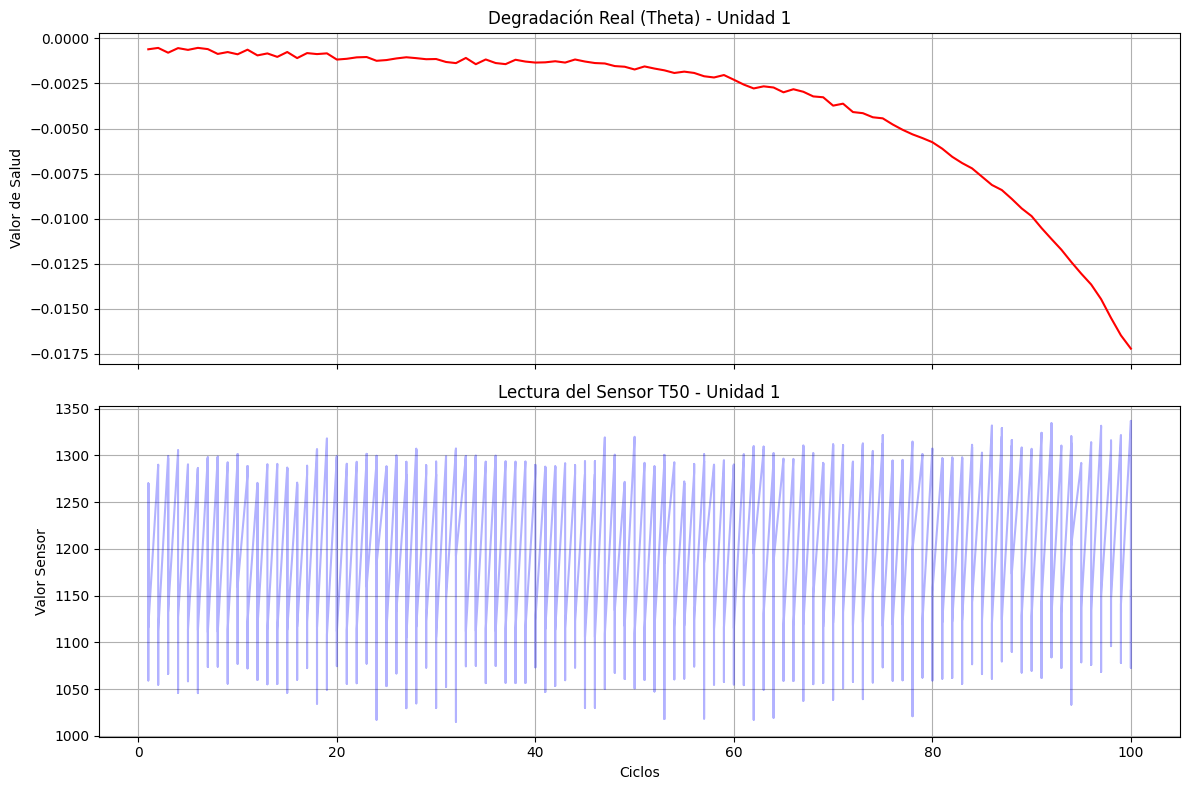

In [8]:
import matplotlib.pyplot as plt
unit_id = 1

with h5py.File(filename, 'r') as hdf:
    # 1. Primero, leemos los nombres de los sensores para encontrar el índice correcto
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Buscamos en qué posición está 'T50'
    # Esto evita el IndexError porque busca dinámicamente
    try:
        t50_index = np.where(sensor_names == 'T50')[0][0]
        print(f"El sensor T50 está en el índice: {t50_index}")
    except IndexError:
        print("El sensor T50 no se encontró. Los sensores disponibles son:", sensor_names)
        # Si no está T50, podrías elegir otro como 'T24' o el último disponible
        t50_index = 0 

    # 2. Extraer datos de la Unidad 1 con la máscara
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    
    cycles = A_dev[mask, 1]
    
    # Extraer Theta (Salud) - En DS01 suele haber solo 2 (HPT y LPT) o incluso 1
    # Vamos a extraer la primera columna de salud disponible
    theta_data = hdf.get('T_dev')[mask, 6] 
    
    # Extraer el sensor usando el índice que encontramos arriba
    sensor_data = hdf.get('X_s_dev')[mask, t50_index]

# 3. Graficar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(cycles, theta_data, color='red')
ax1.set_title(f'Degradación Real (Theta) - Unidad {unit_id}')
ax1.set_ylabel('Valor de Salud')
ax1.grid(True)

ax2.plot(cycles, sensor_data, color='blue', alpha=0.3) # Alpha para ver mejor la densidad
ax2.set_title(f'Lectura del Sensor {sensor_names[t50_index]} - Unidad {unit_id}')
ax2.set_ylabel('Valor Sensor')
ax2.set_xlabel('Ciclos')
ax2.grid(True)

plt.tight_layout()
plt.show()

En esta figura vemos varias cosas interesantes. Graficamos los ciclos con respecto a la eficiencia de la turbina y es evidente que esta va decreciendo a medida que pasan los ciclos. **T50** está a la salida de la turbina de baja presión, es como el EGT, y sube a medida que la eficiencia baja.

Sensores a graficar: ['T24', 'T30', 'T50', 'Wf', 'Nf', 'Nc']


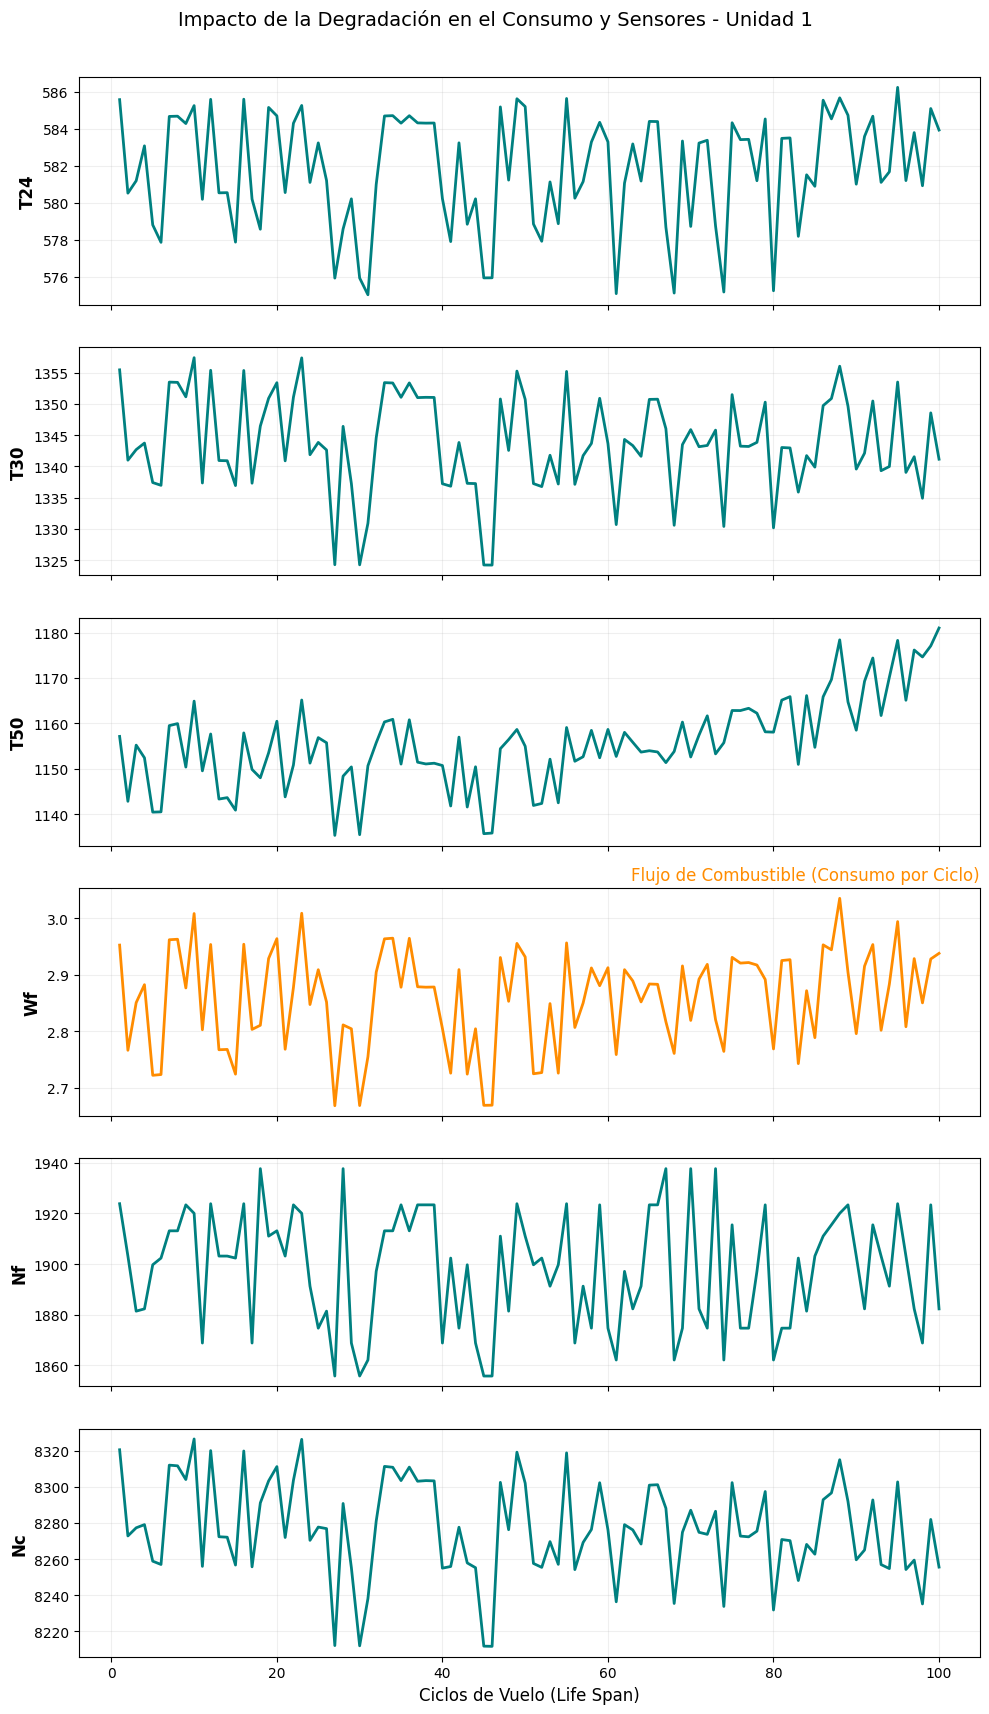

In [9]:
# Agregamos Wf a nuestra lista de deseos
sensores_interesantes = ['T24', 'T30', 'T50', 'P30', 'Wf', 'Nf', 'Nc']

with h5py.File(filename, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Verificamos cuáles existen (Wf suele estar en la posición 10-12 aprox)
    sensores_validos = [s for s in sensores_interesantes if s in sensor_names]
    print(f"Sensores a graficar: {sensores_validos}")

    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    fig, axes = plt.subplots(len(sensores_validos), 1, figsize=(10, 3 * len(sensores_validos)), sharex=True)
    
    if len(sensores_validos) == 1: axes = [axes]

    for i, s_name in enumerate(sensores_validos):
        idx = np.where(sensor_names == s_name)[0][0]
        data_sensor = hdf.get('X_s_dev')[mask, idx]
        
        # Promediado por ciclo
        df_s = pd.DataFrame({'cycle': cycles, 'val': data_sensor})
        df_s_avg = df_s.groupby('cycle').mean()
        
        # Usamos un color naranja para Wf para destacarlo
        color = 'darkorange' if s_name == 'Wf' else 'teal'
        
        axes[i].plot(df_s_avg.index, df_s_avg['val'], color=color, linewidth=2)
        axes[i].set_ylabel(f"{s_name}", fontsize=12, fontweight='bold')
        axes[i].grid(True, alpha=0.2)
        
        if s_name == 'Wf':
            axes[i].set_title("Flujo de Combustible (Consumo por Ciclo)", loc='right', color='darkorange')

axes[-1].set_xlabel('Ciclos de Vuelo (Life Span)', fontsize=12)
plt.suptitle(f'Impacto de la Degradación en el Consumo y Sensores - Unidad {unit_id}', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

**¿Por qué sube la temperatura si el motor se degrada?** Porque para mantener el mismo empuje (thrust) con una turbina menos eficiente, **el sistema de control del motor tiene que quemar más combustible, lo que eleva la temperatura de los gases de escape (EGT o T50)**. Esa relación entre "Baja eficiencia = Sube temperatura" es la base para predecir cuándo va a fallar el motor.

<div class="alert alert-block alert-warning">
La conclusión anterior coincide con la idea de que se quema más combustible. Si se observa la gráfica de *Wf*, que corresponde al flujo de combustible, esta tiende a la alza.

Si observamos la gráfica de T24 que corresponde a la temperatura total a la salida del compresor de baja presión se ve una alza hacia el final de la degradación. Lo que ocurre de acuerdo a la literatura es lo siguiente:

1. Falla en HPT: Menos trabajo extraído por etapa.
2. FADEC aumenta Wf: Sube T48/T50 para mantener el empuje.
3. Efecto Sistema:  El motor opera "más caliente" en general; el aire que entra al HPC (T24) ya viene con una carga térmica mayor por la reducción de eficiencia global del ciclo y posibles efectos de contrapresión del núcleo.

**En términos simples: el motor está "luchando" tanto por mantenerse encendido y con empuje, que todo el bloque térmico se desplaza hacia arriba.**

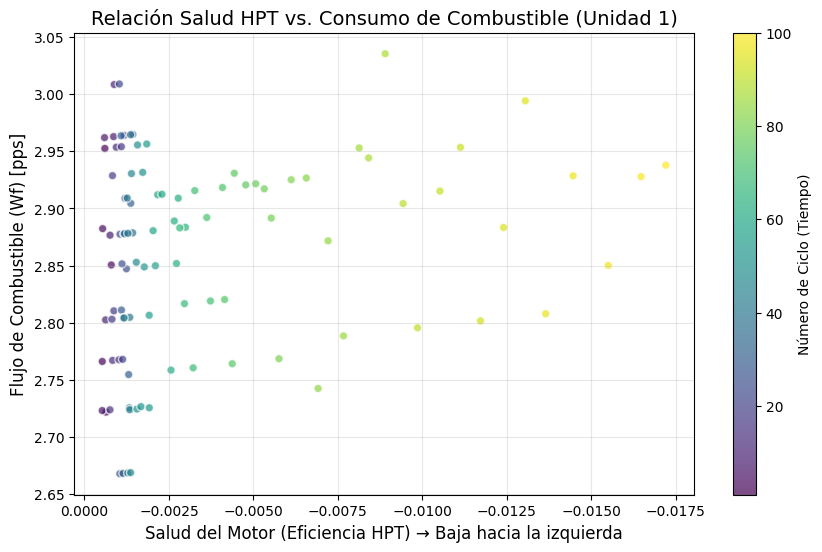

In [10]:
with h5py.File(filename, 'r') as hdf:
    # 1. Obtener nombres y localizar índices
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    # 2. Extraer datos
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    theta_hpt = hdf.get('T_dev')[mask, 6]  # Usamos la columna 6 para HPT
    wf_data = hdf.get('X_s_dev')[mask, wf_idx]

    # 3. Consolidar promedios por ciclo para evitar el ruido de cada segundo
    df_corr = pd.DataFrame({
        'cycle': cycles,
        'salud_hpt': theta_hpt,
        'combustible': wf_data
    })
    df_avg = df_corr.groupby('cycle').mean()

# 4. Graficar la Correlación
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_avg['salud_hpt'], df_avg['combustible'], 
                      c=df_avg.index, cmap='viridis', alpha=0.7, edgecolors='w')

# Añadir barra de color para ver el paso del tiempo (ciclos)
cbar = plt.colorbar(scatter)
cbar.set_label('Número de Ciclo (Tiempo)')

plt.title(f'Relación Salud HPT vs. Consumo de Combustible (Unidad {unit_id})', fontsize=14)
plt.xlabel('Salud del Motor (Eficiencia HPT) → Baja hacia la izquierda', fontsize=12)
plt.ylabel('Flujo de Combustible (Wf) [pps]', fontsize=12)
plt.grid(True, alpha=0.3)

# Invertir el eje X puede ayudar a visualizar el "avance" de la falla
plt.gca().invert_xaxis() 

plt.show()

<div class="alert alert-block alert-warning">
En este gráfico, buscaremos una correlación negativa: a medida que el valor de salud disminuye, el flujo de combustible debería aumentar. Aunque no es una gráfica de 2 dimensiones porque considera tanto la eficiencia como los ciclos, logramos ver la alza por la inyección de combustible. 

1. La dirección de los puntos: Debería ver una tendencia clara que sube hacia la izquierda. Esto confirma que cuando la eficiencia cae, el consumo de combustible sube. 
2. Los Colores: Los colores amarillos/claros representan los últimos ciclos de vida del motor. Deberían estar en la zona de mayor consumo y menor salud.
3. Linealidad: Si los puntos forman casi una línea recta, felicidades: hay un indicador perfecto para el modelo de predicción. **Si están muy dispersos, significa que otros factores (como las condiciones operativas $W$) están afectando el consumo. Por ende hay que considerar más correlaciones.**

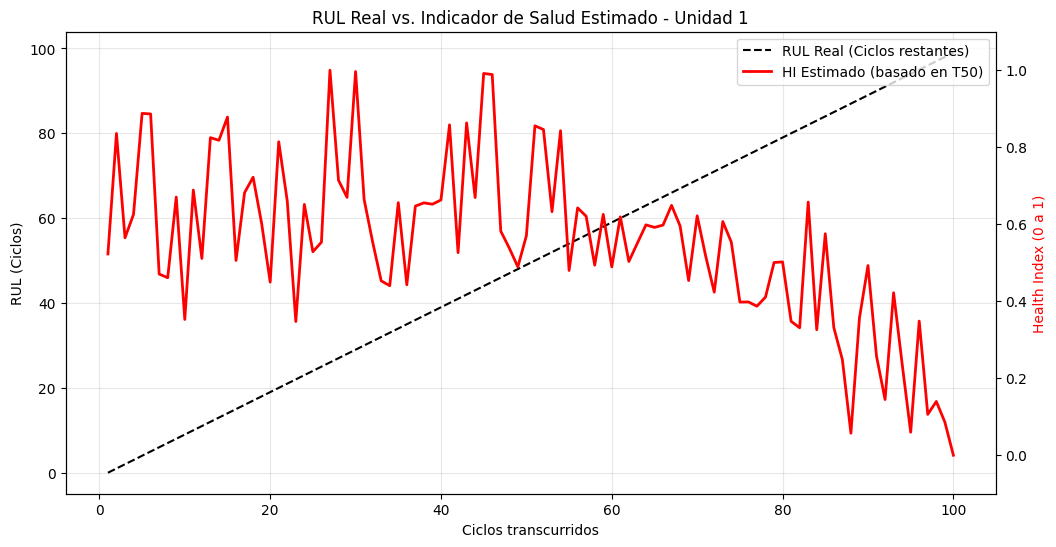

In [11]:
with h5py.File(filename, 'r') as hdf:
    # 1. Extraer datos básicos
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    # 2. Calcular el RUL real
    max_cycle = cycles.max()
    rul_real = max_cycle - cycles
    
    # 3. Crear un HI (Health Index) basado en un sensor (ej. T50)
    # Buscamos T50 para usarlo como "espejo" de la salud
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    t50_idx = np.where(sensor_names == 'T50')[0][0]
    t50_data = hdf.get('X_s_dev')[mask, t50_idx]
    
    # Promediamos por ciclo para que el HI no sea puro ruido
    df_hi = pd.DataFrame({'cycle': cycles, 't50': t50_data})
    df_hi_avg = df_hi.groupby('cycle').mean()
    
    # Normalizamos el T50 para que vaya de 1 (sano) a 0 (fallo)
    # Como T50 sube con el daño, lo invertimos: 1 - (valor normalizado)
    t50_min = df_hi_avg['t50'].min()
    t50_max = df_hi_avg['t50'].max()
    hi_estimado = 1 - ((df_hi_avg['t50'] - t50_min) / (t50_max - t50_min))

# 4. Graficar
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje principal: RUL
ax1.plot(np.unique(cycles), np.unique(rul_real), color='black', linestyle='--', label='RUL Real (Ciclos restantes)')
ax1.set_xlabel('Ciclos transcurridos')
ax1.set_ylabel('RUL (Ciclos)', color='black')
ax1.grid(True, alpha=0.3)

# Eje secundario: Health Index
ax2 = ax1.twinx()
ax2.plot(df_hi_avg.index, hi_estimado, color='red', linewidth=2, label='HI Estimado (basado en T50)')
ax2.set_ylabel('Health Index (0 a 1)', color='red')
ax2.set_ylim(-0.1, 1.1)

plt.title(f'RUL Real vs. Indicador de Salud Estimado - Unidad {unit_id}')
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

1. RUL (Ground Truth): Es la vida útil restante real. Si un motor dura 200 ciclos, en el ciclo 50 su RUL es 150. Es una línea recta descendente que llega a cero.

2. HI (Health Index) estimado: Como aún no hemos entrenado un modelo de Machine Learning, podemos crear un HI basado en sensores. Una técnica común es usar un sensor muy sensible (como el T50 o el Wf) y normalizarlo entre 0 y 1 para que actúe como un "indicador de salud" visual.

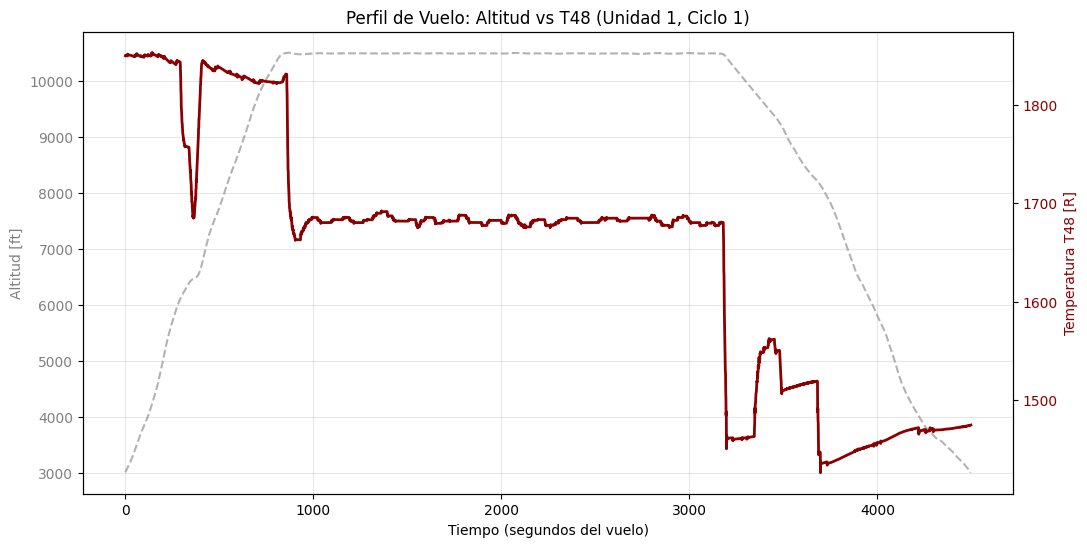

In [12]:
vuelo_id = 1 # Vamos a ver solo el primer vuelo

with h5py.File(filename, 'r') as hdf:
    # 1. Localizar índices de Altitud (en W) y T48 (en X_s)
    w_names = np.array(hdf.get('W_var')).astype(str)
    s_names = np.array(hdf.get('X_s_var')).astype(str)
    
    alt_idx = np.where(w_names == 'alt')[0][0]
    t48_idx = np.where(s_names == 'T48')[0][0]
    
    # 2. Extraer datos de la Unidad 1
    A_dev = hdf.get('A_dev')[:]
    # Máscara doble: Unidad 1 Y Ciclo 1
    mask_vuelo = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == vuelo_id)
    
    alt_data = hdf.get('W_dev')[mask_vuelo, alt_idx]
    t48_data = hdf.get('X_s_dev')[mask_vuelo, t48_idx]
    
    # Creamos un eje de tiempo (puntos de datos)
    time_steps = np.arange(len(alt_data))

# 3. Graficar
fig, ax1 = plt.subplots(figsize=(12, 6))

# Altitud (Eje Izquierdo)
ax1.plot(time_steps, alt_data, color='gray', linestyle='--', alpha=0.6, label='Altitud')
ax1.set_xlabel('Tiempo (segundos del vuelo)')
ax1.set_ylabel('Altitud [ft]', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# T48 (Eje Derecho)
ax2 = ax1.twinx()
ax2.plot(time_steps, t48_data, color='darkred', linewidth=2, label='Temperatura T48')
ax2.set_ylabel('Temperatura T48 [R]', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title(f'Perfil de Vuelo: Altitud vs T48 (Unidad {unit_id}, Ciclo {vuelo_id})')
ax1.grid(True, alpha=0.3)
plt.show()

**¿Qué observamos en esta gráfica?**

1. El Despegue (Take-off): Al inicio del tiempo, verás que la Altitud es baja pero la T48 se dispara. Es el momento de máximo estrés térmico del motor; necesita toda la potencia para elevar el avión.

2. El Ascenso: A medida que la línea gris sube, la T48 empieza a bajar un poco porque el aire exterior es más frío y el motor se estabiliza.

3. Crucero (Cruise): Verás una meseta larga en la altitud. La T48 aquí es más baja y estable. Es donde el motor pasa el 90% de su vida.

4. Descenso y Aterrizaje: Verás que la altitud cae y la T48 baja a niveles de "IDLE" (ralentí), con un pequeño pico final al tocar pista si se usan los reversibles.

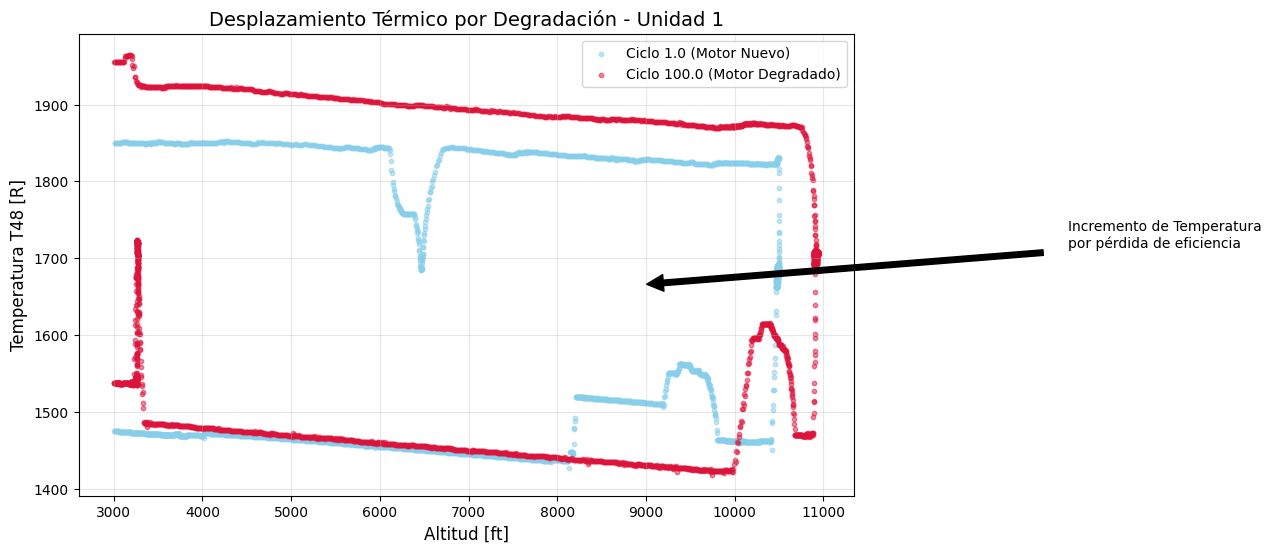

In [13]:
with h5py.File(filename, 'r') as hdf:
    # 1. Localizar índices
    w_names = np.array(hdf.get('W_var')).astype(str)
    s_names = np.array(hdf.get('X_s_var')).astype(str)
    alt_idx = np.where(w_names == 'alt')[0][0]
    t48_idx = np.where(s_names == 'T48')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    u_mask = A_dev[:, 0] == unit_id
    vuelos_disponibles = np.unique(A_dev[u_mask, 1])
    
    ciclo_joven = vuelos_disponibles[0]  # Ciclo 1
    ciclo_viejo = vuelos_disponibles[-1] # Último ciclo antes de falla
    
    # 2. Extraer datos para ambos ciclos
    def get_vuelo_data(c_id):
        mask = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == c_id)
        return hdf.get('W_dev')[mask, alt_idx], hdf.get('X_s_dev')[mask, t48_idx]

    alt_joven, t48_joven = get_vuelo_data(ciclo_joven)
    alt_viejo, t48_viejo = get_vuelo_data(ciclo_viejo)

# 3. Graficar
plt.figure(figsize=(10, 6))

# Usamos scatter porque los puntos no están necesariamente en orden de altitud
plt.scatter(alt_joven, t48_joven, color='skyblue', alpha=0.5, s=10, label=f'Ciclo {ciclo_joven} (Motor Nuevo)')
plt.scatter(alt_viejo, t48_viejo, color='crimson', alpha=0.5, s=10, label=f'Ciclo {ciclo_viejo} (Motor Degradado)')

plt.title(f'Desplazamiento Térmico por Degradación - Unidad {unit_id}', fontsize=14)
plt.xlabel('Altitud [ft]', fontsize=12)
plt.ylabel('Temperatura T48 [R]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Añadir una flecha que indique el desplazamiento
plt.annotate('Incremento de Temperatura\npor pérdida de eficiencia', 
             xy=(alt_joven.mean(), t48_viejo.mean()), 
             xytext=(alt_joven.mean() + 5000, t48_viejo.mean() + 50),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

**¿Qué estás viendo aquí?**

1. El "Shift" (Desplazamiento): Verás que la nube de puntos roja (vieja) está sistemáticamente por encima de la nube azul (nueva).

2. Misma Altitud, Distinta Temp: Si trazas una línea vertical en cualquier altitud (ej. 30,000 ft), verás que el motor degradado opera varios grados más caliente.

3. Física del Fallo: La turbina de alta presión (HPT) ya no es capaz de extraer energía del flujo de manera eficiente. Para compensar y mantener la altitud/velocidad, el motor quema más combustible, elevando la temperatura de los gases.

En el N-CMAPSS, la duración no es fija. Hay vuelos cortos, medianos y largos (las llamadas Flight Classes). Vamos a calcular cuánto dura cada vuelo de la Unidad 1 para que veas esa variabilidad:

In [14]:
with h5py.File(filename, 'r') as hdf:
    A_dev = hdf.get('A_dev')[:]
    mask_u1 = A_dev[:, 0] == 1
    
    # Extraemos ciclos y clases de vuelo (Fc está en la col 2 de A)
    ciclos_u1 = A_dev[mask_u1, 1]
    clases_u1 = A_dev[mask_u1, 2]

# Calcular duración por ciclo (contando cuántas filas hay por cada ID de ciclo)
df_duracion = pd.DataFrame({'ciclo': ciclos_u1, 'clase': clases_u1})
duracion_por_ciclo = df_duracion.groupby('ciclo').size() # Tamaño = segundos totales
clase_por_ciclo = df_duracion.groupby('ciclo')['clase'].first()

# Unimos la info
resumen_vuelos = pd.DataFrame({
    'Duracion_Segundos': duracion_por_ciclo,
    'Duracion_Minutos': duracion_por_ciclo / 60,
    'Flight_Class': clase_por_ciclo
})

print("Resumen de los primeros 10 vuelos (Unidad 1):")
print(resumen_vuelos.head(10))

Resumen de los primeros 10 vuelos (Unidad 1):
       Duracion_Segundos  Duracion_Minutos  Flight_Class
ciclo                                                   
1.0                 4498         74.966667           1.0
2.0                 4660         77.666667           1.0
3.0                 5355         89.250000           1.0
4.0                 4181         69.683333           1.0
5.0                 4495         74.916667           1.0
6.0                 5069         84.483333           1.0
7.0                 3814         63.566667           1.0
8.0                 3814         63.566667           1.0
9.0                 4462         74.366667           1.0
10.0                5378         89.633333           1.0


**¿Por qué esto cambia las reglas del juego para el modelo?**

1. Carga de Trabajo Real: En el viejo CMAPSS, un ciclo era un ciclo. Aquí, un ciclo de la Flight Class 3 (vuelo largo) desgasta el motor de forma diferente a uno de la Flight Class 1 (vuelo corto).

2. Mantenimiento basado en horas, no solo ciclos: Ahora puedes calcular el Total Flight Hours (TFH) acumulado, que es como se mide el mantenimiento en la vida real.

3. Análisis de Transitorios: Puedes analizar el despegue (donde la temperatura sube más rápido). El CMAPSS viejo ignoraba esto por completo.

Como ahora tienes tiempo, el RUL se puede calcular de dos formas:

* RUL en ciclos: "Le quedan 50 vuelos".

* RUL en tiempo: "Le quedan 120 horas de vuelo"

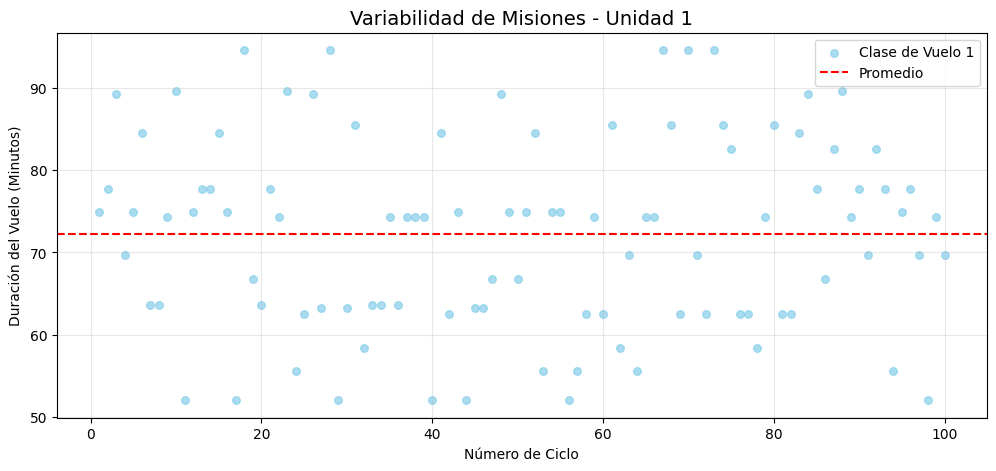

In [15]:
import h5py
import pandas as pd
import matplotlib.pyplot as plt

filename = 'N-CMAPSS_DS01-005.h5'
unit_id = 1

with h5py.File(filename, 'r') as hdf:
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    
    # Extraemos Ciclo y Clase de Vuelo (Columna 2 de A_dev)
    df_vuelos = pd.DataFrame({
        'ciclo': A_dev[mask, 1],
        'clase': A_dev[mask, 2]
    })

# Calculamos duración contando filas (cada fila es 1 segundo)
resumen = df_vuelos.groupby('ciclo').agg(
    duracion_min=('clase', 'count'),
    clase_vuelo=('clase', 'first')
).reset_index()
resumen['duracion_min'] /= 60  # Convertir segundos a minutos

# Graficar
plt.figure(figsize=(12, 5))
colores = {1: 'skyblue', 2: 'orange', 3: 'green'}

for clase in sorted(resumen['clase_vuelo'].unique()):
    mask_clase = resumen['clase_vuelo'] == clase
    plt.scatter(resumen.loc[mask_clase, 'ciclo'], 
                resumen.loc[mask_clase, 'duracion_min'], 
                label=f'Clase de Vuelo {int(clase)}',
                c=colores[clase], s=30, alpha=0.7)

plt.axhline(resumen['duracion_min'].mean(), color='red', linestyle='--', label='Promedio')
plt.title(f'Variabilidad de Misiones - Unidad {unit_id}', fontsize=14)
plt.xlabel('Número de Ciclo')
plt.ylabel('Duración del Vuelo (Minutos)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
with h5py.File(filename, 'r') as hdf:
    A_dev = hdf.get('A_dev')[:]
    
    for uid in range(1, 6):
        mask = A_dev[:, 0] == uid
        clases = np.unique(A_dev[mask, 2])
        print(f"Unidad {uid}: Clases de vuelo detectadas -> {clases}")

Unidad 1: Clases de vuelo detectadas -> [1.]
Unidad 2: Clases de vuelo detectadas -> [3.]
Unidad 3: Clases de vuelo detectadas -> [2.]
Unidad 4: Clases de vuelo detectadas -> [1.]
Unidad 5: Clases de vuelo detectadas -> [3.]


Presiones encontradas: [np.str_('P15'), np.str_('P2'), np.str_('P21'), np.str_('P24'), np.str_('Ps30'), np.str_('P40'), np.str_('P50')]


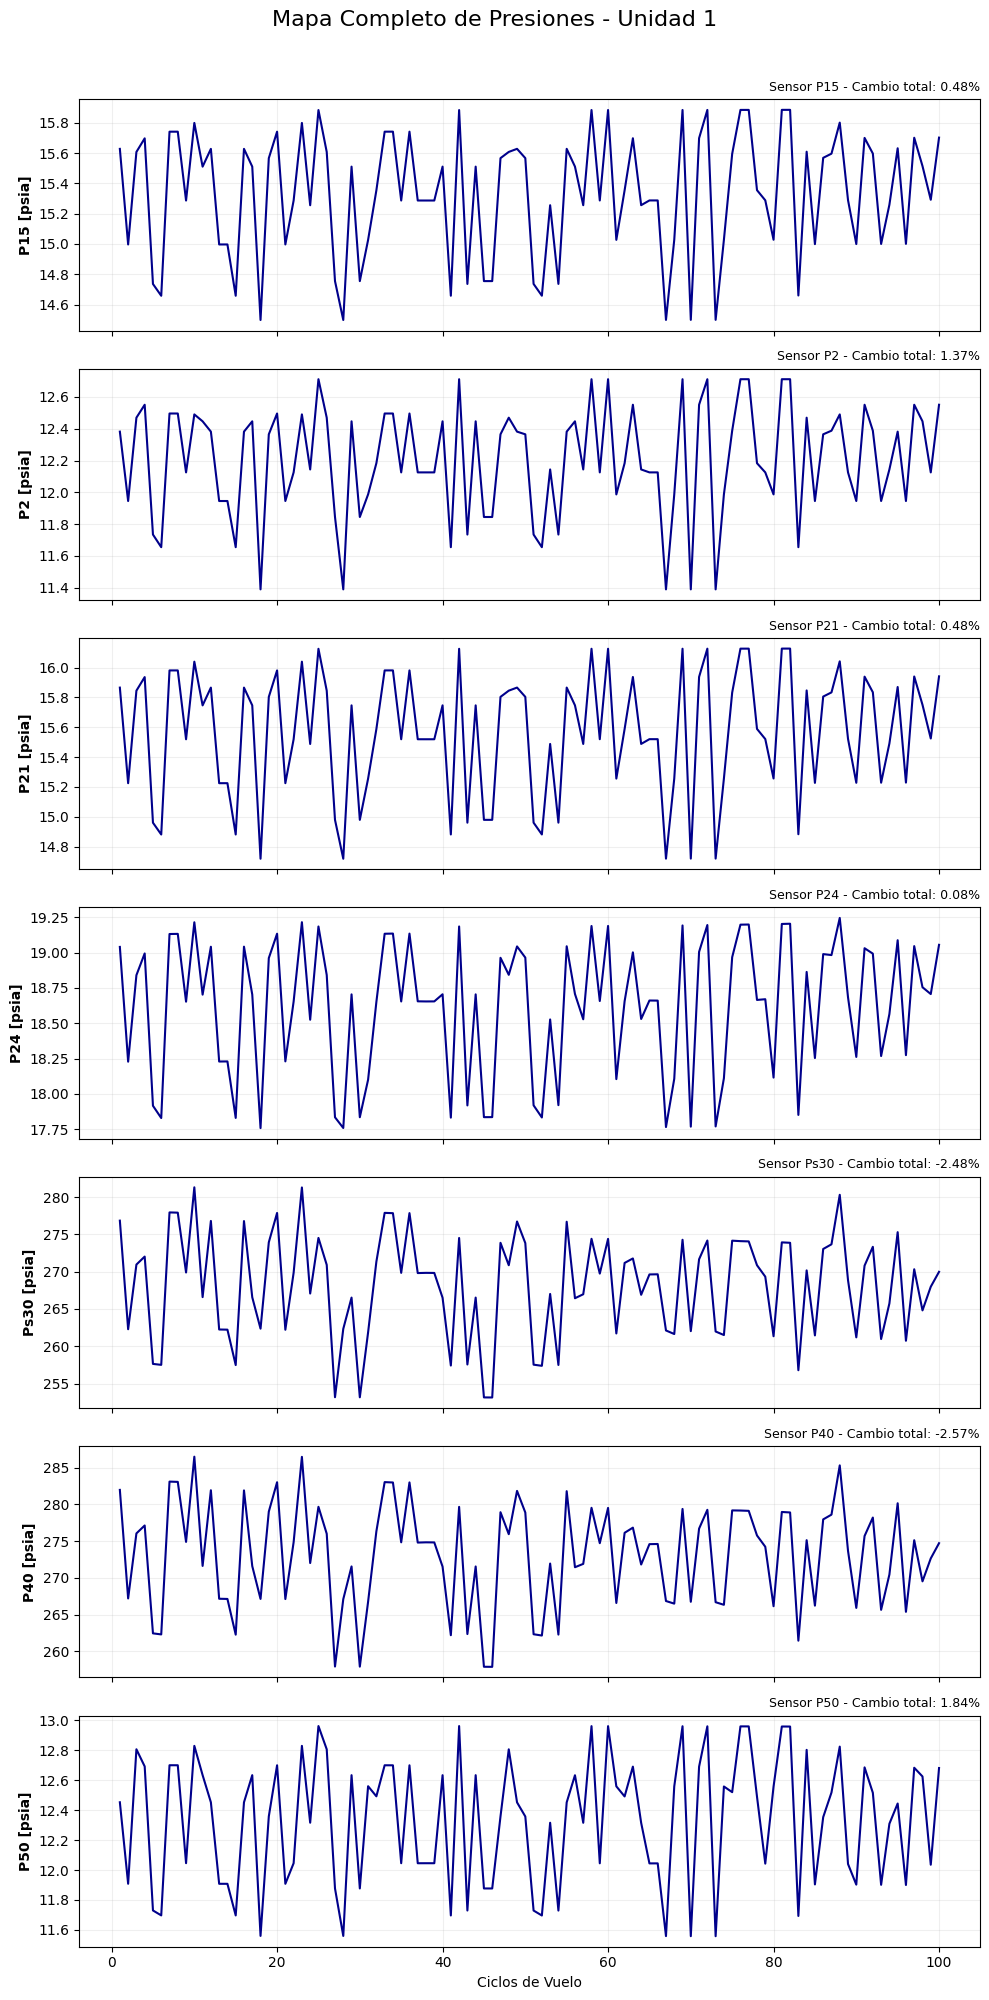

In [17]:
with h5py.File(filename, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Identificamos todos los sensores que empiezan con 'P'
    presiones_disponibles = [s for s in sensor_names if s.startswith('P')]
    print(f"Presiones encontradas: {presiones_disponibles}")
    
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]

    # Configuramos una cuadrícula de subplots
    n_p = len(presiones_disponibles)
    fig, axes = plt.subplots(n_p, 1, figsize=(10, 3 * n_p), sharex=True)
    
    # Aseguramos que axes sea una lista si solo hay una presión
    if n_p == 1: axes = [axes]

    for i, p_name in enumerate(presiones_disponibles):
        idx = np.where(sensor_names == p_name)[0][0]
        data_raw = hdf.get('X_s_dev')[mask, idx]
        
        # Promedio por ciclo para ver la tendencia limpia
        df_tmp = pd.DataFrame({'cycle': cycles, 'val': data_raw})
        df_avg = df_tmp.groupby('cycle').mean()
        
        axes[i].plot(df_avg.index, df_avg['val'], color='darkblue', linewidth=1.5)
        axes[i].set_ylabel(f"{p_name} [psia]", fontweight='bold')
        axes[i].grid(True, alpha=0.2)
        
        # Calcular el cambio porcentual total para ver qué tanto varió
        delta = ((df_avg['val'].iloc[-1] - df_avg['val'].iloc[0]) / df_avg['val'].iloc[0]) * 100
        axes[i].set_title(f"Sensor {p_name} - Cambio total: {delta:.2f}%", loc='right', fontsize=9)

axes[-1].set_xlabel('Ciclos de Vuelo')
plt.suptitle(f'Mapa Completo de Presiones - Unidad {unit_id}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

<div class="alert alert-block alert-danger">
Recuerda que estas presiones están influenciadas por la Altitud y la Velocidad (Mach). Al promediarlas por ciclo, estamos asumiendo que todos los vuelos de "Clase 1" son lo suficientemente parecidos para comparar sus promedios. En el DS01 esto funciona muy bien porque, como descubriste, todos son Clase 1.

Lo primero que notamos es que Ps30, P40 tienden a la baja, y P50 tiende a subir. P2 no tiene cambios significativos, es una línea casi horizontal con un cambio del 0.01%, es normal. P2 es la presión de entrada y depende del ambiente, no de qué tan dañado esté el motor por dentro. P50 suele subir. Si la turbina no es eficiente, "deja pasar" más presión y calor hacia el escape porque no pudo transformarlos en energía mecánica para mover el eje.

1. Menos capacidad de succión: Una turbina degradada (con mayor claridad entre álabes y carcasa o daños en el perfil aerodinámico) no es capaz de "procesar" el flujo de aire de manera tan eficiente. Esto crea una restricción o un cambio en el punto de operación del compresor de alta (HPC).

2. Caída en la relación de presiones: Al perder eficiencia la HPT, esta le entrega menos potencia al eje que mueve al compresor (HPC). Como el HPC gira con menos "fuerza" efectiva o se ve afectado por el flujo de la turbina, su capacidad para comprimir el aire disminuye. Por lo tanto, la presión al final del compresor (Ps30) y la que entra a la turbina (P40) caen a medida que el sistema se vuelve incapaz de mantener la compresión de diseño.

Aquí es donde entra la compensación del motor. Recuerda que el motor intenta mantener el empuje (Thrust) solicitado.

1. Aumento de la energía térmica: Como viste antes, el FADEC inyecta más combustible (Wf) para compensar la ineficiencia de la HPT. Esto eleva la temperatura y la entalpía del gas.

2. Efecto de "Bloqueo" y Expansión Ineficiente: En una turbina sana, la energía (presión y temperatura) se convierte eficientemente en trabajo mecánico. En una turbina degradada, el gas "atraviesa" la HPT sin entregar toda la energía que debería.

3. Mayor presión residual: Ese exceso de energía que la HPT no pudo aprovechar llega a la Turbina de Baja Presión (LPT). Como la LPT ahora recibe un flujo con mayor carga térmica y volumen debido a la ineficiencia previa, la presión a su salida (P50) aumenta. Básicamente, el gas sale de la sección de alta presión con más energía residual de la que debería, "inflando" la presión en la última etapa antes de la boquilla de salida.

<div class="alert alert-block alert-info">
Para ver con claridad la degradación voy a graficar la relación entre P40 y P50.

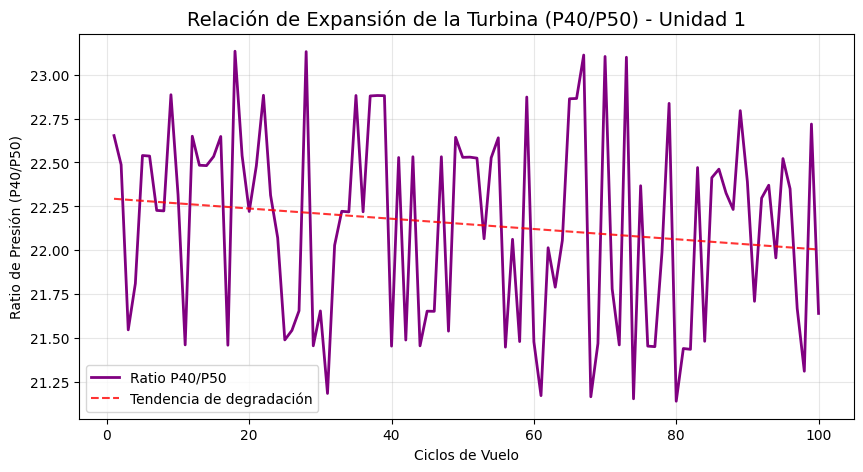

Ratio inicial: 22.6529
Ratio final: 21.6410


In [18]:
with h5py.File(filename, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # Verificamos si P40 y P50 existen en el dataset
    if 'P40' in sensor_names and 'P50' in sensor_names:
        idx_p40 = np.where(sensor_names == 'P40')[0][0]
        idx_p50 = np.where(sensor_names == 'P50')[0][0]
        
        A_dev = hdf.get('A_dev')[:]
        mask = A_dev[:, 0] == unit_id
        cycles = A_dev[mask, 1]
        
        # Extraemos datos
        p40_data = hdf.get('X_s_dev')[mask, idx_p40]
        p50_data = hdf.get('X_s_dev')[mask, idx_p50]
        
        # Creamos el DataFrame para promediar por ciclo
        df_ratio = pd.DataFrame({
            'cycle': cycles,
            'ratio': p40_data / p50_data
        })
        df_avg = df_ratio.groupby('cycle').mean()
        
        # Graficamos
        plt.figure(figsize=(10, 5))
        plt.plot(df_avg.index, df_avg['ratio'], color='purple', linewidth=2, label='Ratio P40/P50')
        
        # Añadir línea de tendencia
        z = np.polyfit(df_avg.index, df_avg['ratio'], 1)
        p = np.poly1d(z)
        plt.plot(df_avg.index, p(df_avg.index), "r--", alpha=0.8, label='Tendencia de degradación')
        
        plt.title(f'Relación de Expansión de la Turbina (P40/P50) - Unidad {unit_id}', fontsize=14)
        plt.xlabel('Ciclos de Vuelo')
        plt.ylabel('Ratio de Presión (P40/P50)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"Ratio inicial: {df_avg['ratio'].iloc[0]:.4f}")
        print(f"Ratio final: {df_avg['ratio'].iloc[-1]:.4f}")
    else:
        print("Lo siento, P40 o P50 no están disponibles en este dataset (DS01).")
        print(f"Sensores disponibles: {[s for s in sensor_names if s.startswith('P')]}")

En un ciclo ideal, quieres que $P40$ sea muy alta y $P50$ sea lo más baja posible (dentro de los límites de diseño), porque esa diferencia de presión es la que empuja los álabes para generar torque. Si el ratio baja, la turbina está dejando escapar presión sin convertirla en movimiento. Además, la degradación mecánica (erosión, aumento de claros en las puntas de los álabes) crea turbulencia. Esa turbulencia impide que la presión caiga de forma controlada y útil, haciendo que el gas llegue a la estación 50 todavía "inflado" y caliente.

<div class="alert alert-block alert-success">
Mientras que las presiones individuales ($P40$ o $P50$) pueden fluctuar por cambios en la altitud o la temperatura exterior, el ratio es mucho más estable. El hecho de que tu línea sea descendente y clara confirma que la unidad 1 está perdiendo su capacidad de extraer energía de forma progresiva.

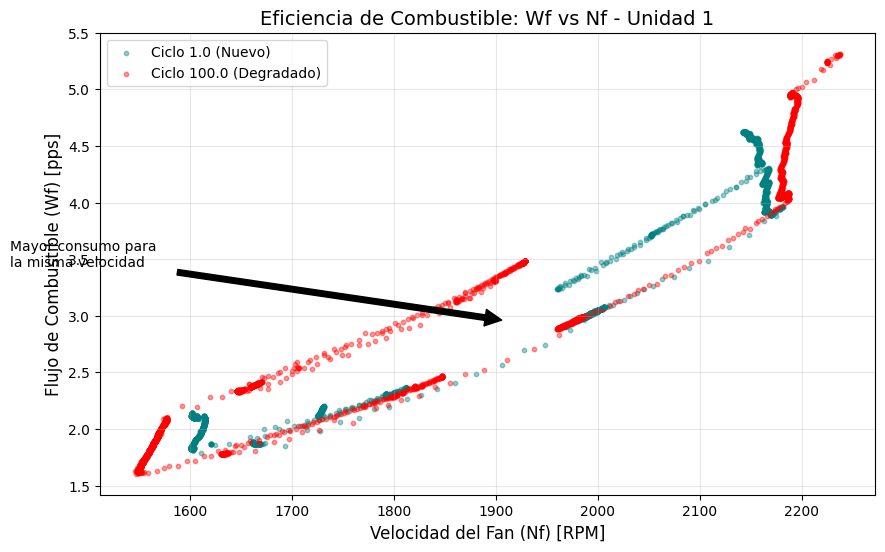

In [19]:
with h5py.File(filename, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # 1. Localizar índices de Nf (Fan Speed) y Wf (Fuel Flow)
    nf_idx = np.where(sensor_names == 'Nf')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    u_mask = A_dev[:, 0] == unit_id
    vuelos = np.unique(A_dev[u_mask, 1])
    
    ciclo_ini = vuelos[0]
    ciclo_fin = vuelos[-1]
    
    # 2. Extraer datos (Unidad 1, Ciclos primero y último)
    mask_ini = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == ciclo_ini)
    mask_fin = (A_dev[:, 0] == unit_id) & (A_dev[:, 1] == ciclo_fin)
    
    nf_ini, wf_ini = hdf.get('X_s_dev')[mask_ini, nf_idx], hdf.get('X_s_dev')[mask_ini, wf_idx]
    nf_fin, wf_fin = hdf.get('X_s_dev')[mask_fin, nf_idx], hdf.get('X_s_dev')[mask_fin, wf_idx]

# 3. Graficar la relación
plt.figure(figsize=(10, 6))

plt.scatter(nf_ini, wf_ini, color='teal', alpha=0.4, s=10, label=f'Ciclo {ciclo_ini} (Nuevo)')
plt.scatter(nf_fin, wf_fin, color='red', alpha=0.4, s=10, label=f'Ciclo {ciclo_fin} (Degradado)')

plt.title(f'Eficiencia de Combustible: Wf vs Nf - Unidad {unit_id}', fontsize=14)
plt.xlabel('Velocidad del Fan (Nf) [RPM]', fontsize=12)
plt.ylabel('Flujo de Combustible (Wf) [pps]', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Dibujar una flecha para mostrar el "Fuel Penalty"
plt.annotate('Mayor consumo para\nla misma velocidad', 
             xy=(nf_ini.mean(), wf_fin.mean()), 
             xytext=(nf_ini.mean() - 500, wf_fin.mean() + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

**¿Qué se analiza en esta gráfica?**
1. El desplazamiento vertical: Para cualquier punto en el eje X (por ejemplo, a 8000 RPM), verás que los puntos rojos están por encima de los azules. Esa distancia vertical es el exceso de combustible que el motor está desperdiciando debido a la degradación.

2. La "Pendiente" de la salud: Si el motor fuera perfecto, ambas nubes de puntos estarían una encima de la otra. La separación entre ellas es un indicador directo del Estado de Salud (Health Index).

3. Variabilidad: Verás que los puntos forman una línea o curva. Esto es porque durante el vuelo la velocidad del Fan cambia (despegue vs. crucero), y el combustible siempre lo sigue.

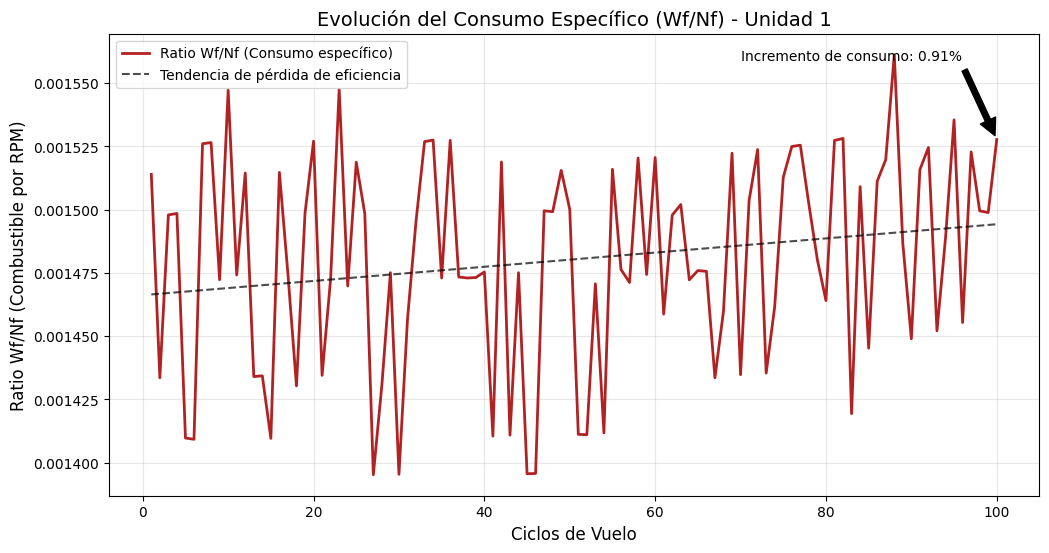

In [20]:
with h5py.File(filename, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    # 1. Localizar índices
    nf_idx = np.where(sensor_names == 'Nf')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    
    A_dev = hdf.get('A_dev')[:]
    mask = A_dev[:, 0] == unit_id
    cycles = A_dev[mask, 1]
    
    # 2. Extraer datos y calcular el ratio segundo a segundo
    nf_data = hdf.get('X_s_dev')[mask, nf_idx]
    wf_data = hdf.get('X_s_dev')[mask, wf_idx]
    
    # Creamos el ratio
    ratio_data = wf_data / nf_data
    
    # 3. Consolidar por ciclo para eliminar el ruido transitorio
    df_ratio = pd.DataFrame({'cycle': cycles, 'ratio': ratio_data})
    df_avg = df_ratio.groupby('cycle').mean()

# 4. Graficar la evolución
plt.figure(figsize=(12, 6))
plt.plot(df_avg.index, df_avg['ratio'], color='firebrick', linewidth=2, label='Ratio Wf/Nf (Consumo específico)')

# Añadir una línea de tendencia para ver la pendiente de degradación
z = np.polyfit(df_avg.index, df_avg['ratio'], 1)
p = np.poly1d(z)
plt.plot(df_avg.index, p(df_avg.index), "k--", alpha=0.7, label='Tendencia de pérdida de eficiencia')

plt.title(f'Evolución del Consumo Específico (Wf/Nf) - Unidad {unit_id}', fontsize=14)
plt.xlabel('Ciclos de Vuelo', fontsize=12)
plt.ylabel('Ratio Wf/Nf (Combustible por RPM)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Anotación del incremento porcentual
inc_perc = ((df_avg['ratio'].iloc[-1] - df_avg['ratio'].iloc[0]) / df_avg['ratio'].iloc[0]) * 100
plt.annotate(f'Incremento de consumo: {inc_perc:.2f}%', 
             xy=(df_avg.index[-1], df_avg['ratio'].iloc[-1]),
             xytext=(df_avg.index[-1]-30, df_avg['ratio'].iloc[-1] + (df_avg['ratio'].max()*0.02)),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

<div class="alert alert-block alert-success">
Efectivamente el ratio se va incrementando porque aunque la velocidad se mantiene, la demanda de combustible sube para compensar la pérdida de la turbina de alta presión.

<h2 style="color:teal;">Visualizaciones Iniciales: Motor 2 y 3 - Flight Class 2 y 3</h2>
<p>El objetivo en este punto es determinar si mis conclusiones anteriores coinciden debidamente con los patrones de degradación que descubrí para el motor 1 asociado a fallas de eficiencia en la turbina de alta presión (HPT).<p>

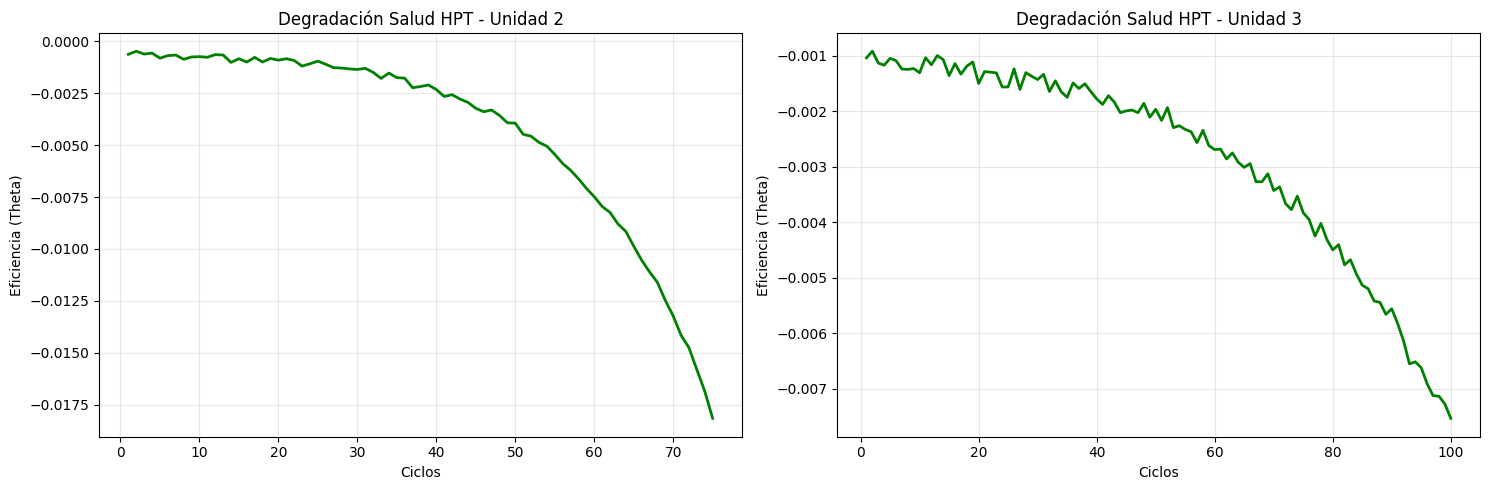

In [21]:
unidades = [2, 3]

with h5py.File(filename, 'r') as hdf:
    A_dev = hdf.get('A_dev')[:]
    T_dev = hdf.get('T_dev')[:]
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    for i, uid in enumerate(unidades):
        mask = A_dev[:, 0] == uid
        # La salud (Theta) está en la primera columna de T_dev
        salud = T_dev[mask, 6]
        ciclos = A_dev[mask, 1]
        
        # Promedio por ciclo para suavizar
        df_s = pd.DataFrame({'cycle': ciclos, 'health': salud}).groupby('cycle').mean()
        
        ax[i].plot(df_s.index, df_s['health'], color='green', linewidth=2)
        ax[i].set_title(f'Degradación Salud HPT - Unidad {uid}')
        ax[i].set_xlabel('Ciclos')
        ax[i].set_ylabel('Eficiencia (Theta)')
        ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
Veo una degradación mucho más suave para la unidad 2, y una más agresiva de la unidad 3, como si a este motor le hicieran mantenimiento más frecuentemente para mantener su eficiencia. Pero, la degradación está, es evidente.

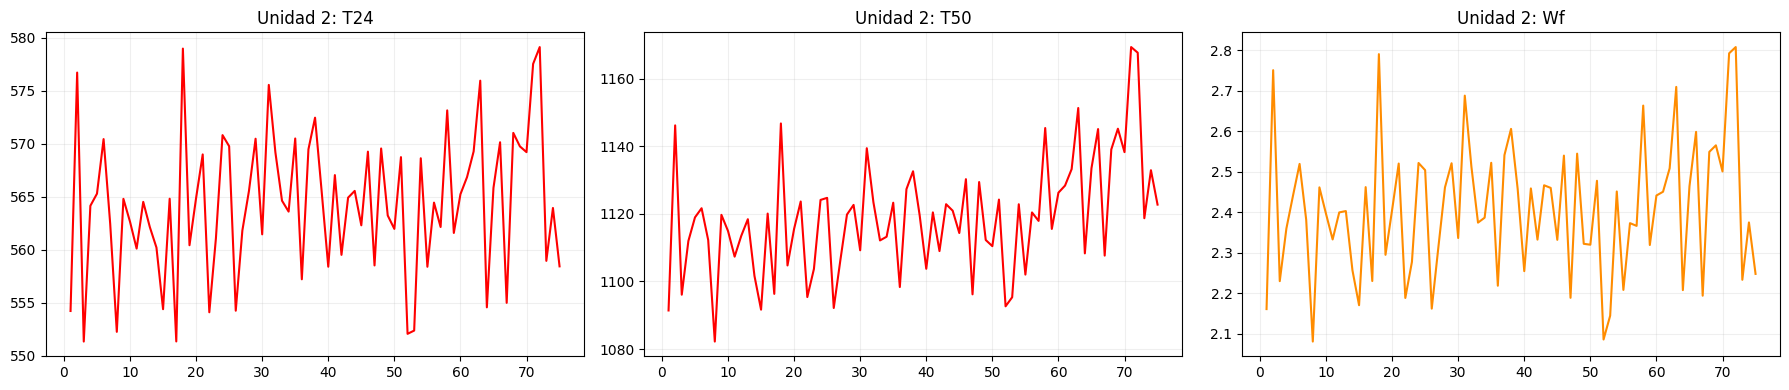

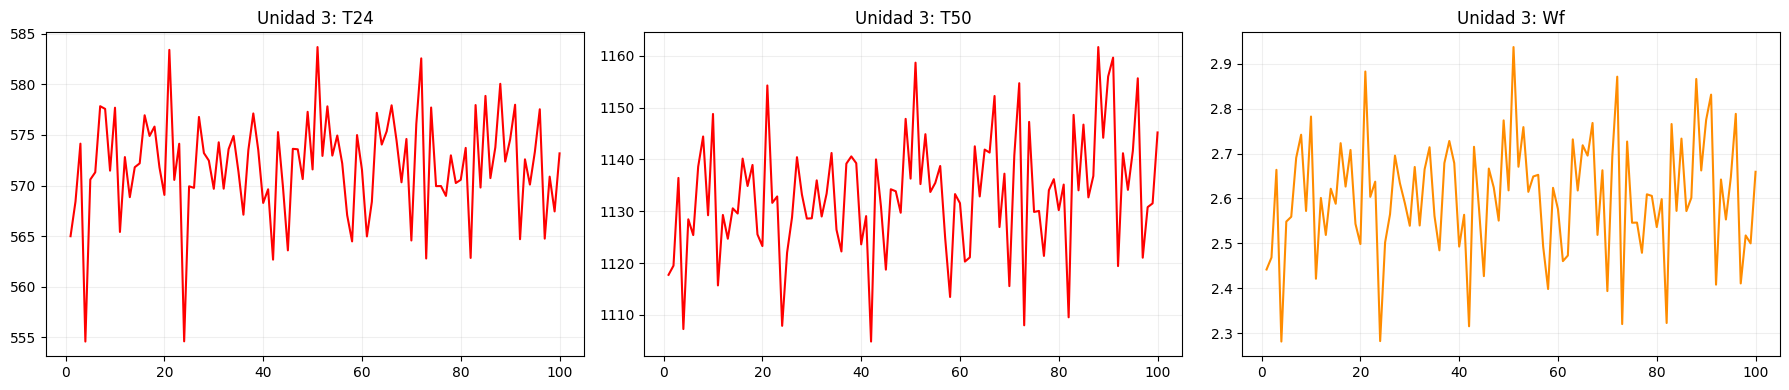

In [22]:
sensores_termicos = ['T24', 'T50', 'Wf']

with h5py.File(filename, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    
    for uid in unidades:
        mask = A_dev[:, 0] == uid
        cycles = A_dev[mask, 1]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        for j, s_name in enumerate(sensores_termicos):
            idx = np.where(sensor_names == s_name)[0][0]
            data = hdf.get('X_s_dev')[mask, idx]
            
            df_avg = pd.DataFrame({'c': cycles, 'v': data}).groupby('c').mean()
            
            axes[j].plot(df_avg.index, df_avg['v'], color='darkorange' if s_name=='Wf' else 'red')
            axes[j].set_title(f'Unidad {uid}: {s_name}')
            axes[j].grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

1. El aumento de la "línea de base"
Aunque hay picos y valles muy pronunciados (propios de misiones más largas donde el motor cambia de régimen según la altitud y velocidad Mach), si trazas una línea imaginaria por el promedio de los puntos bajos:

    * En la Unidad 2, empiezas cerca de 2.2 y terminas viendo muchos más puntos por encima de 2.4 o incluso tocando el 2.8 al final.
    * En la Unidad 3, la tendencia al alza es más clara; el "piso" del consumo sube gradualmente a medida que avanzan los ciclos.

2. Por qué no se ve tan lineal como la temperatura?
Las temperaturas ($T_{24}, T_{50}$) son indicadores térmicos directos de la ineficiencia. El combustible ($W_f$), en cambio, es la variable de control:
    
    * En misiones Tipo 2 y 3, el FADEC ajusta el $W_f$ constantemente para mantener el empuje necesario ante cambios de densidad del aire.
    * Ese "ruido" que ves son las diferentes condiciones de vuelo de cada ciclo. Sin embargo, el hecho de que los picos finales de $W_f$ sean más altos que los iniciales confirma que el motor está "bebiendo" más para compensar la fatiga de la turbina.

3. El fenómeno del "Envejecimiento"
Fíjate en la Unidad 2: Wf entre los ciclos 60 y 75. Hay una densidad mucho mayor de puntos altos en comparación con los primeros 20 ciclos. Esa es la señal de que, para realizar el mismo tipo de misión, el motor ahora requiere un flujo de combustible significativamente mayor.

Sensores detectados: ['P21', 'P24', 'Ps30', 'P40', 'P50']


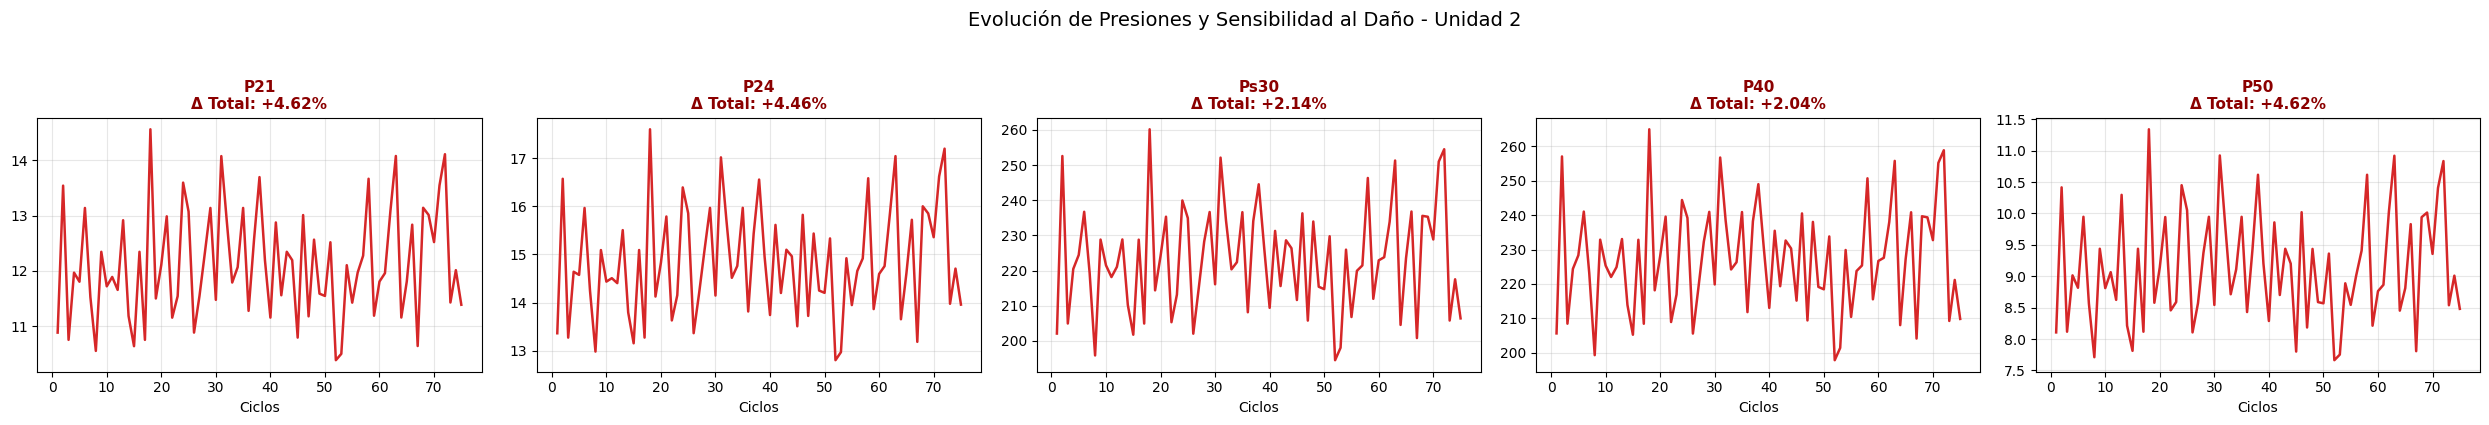

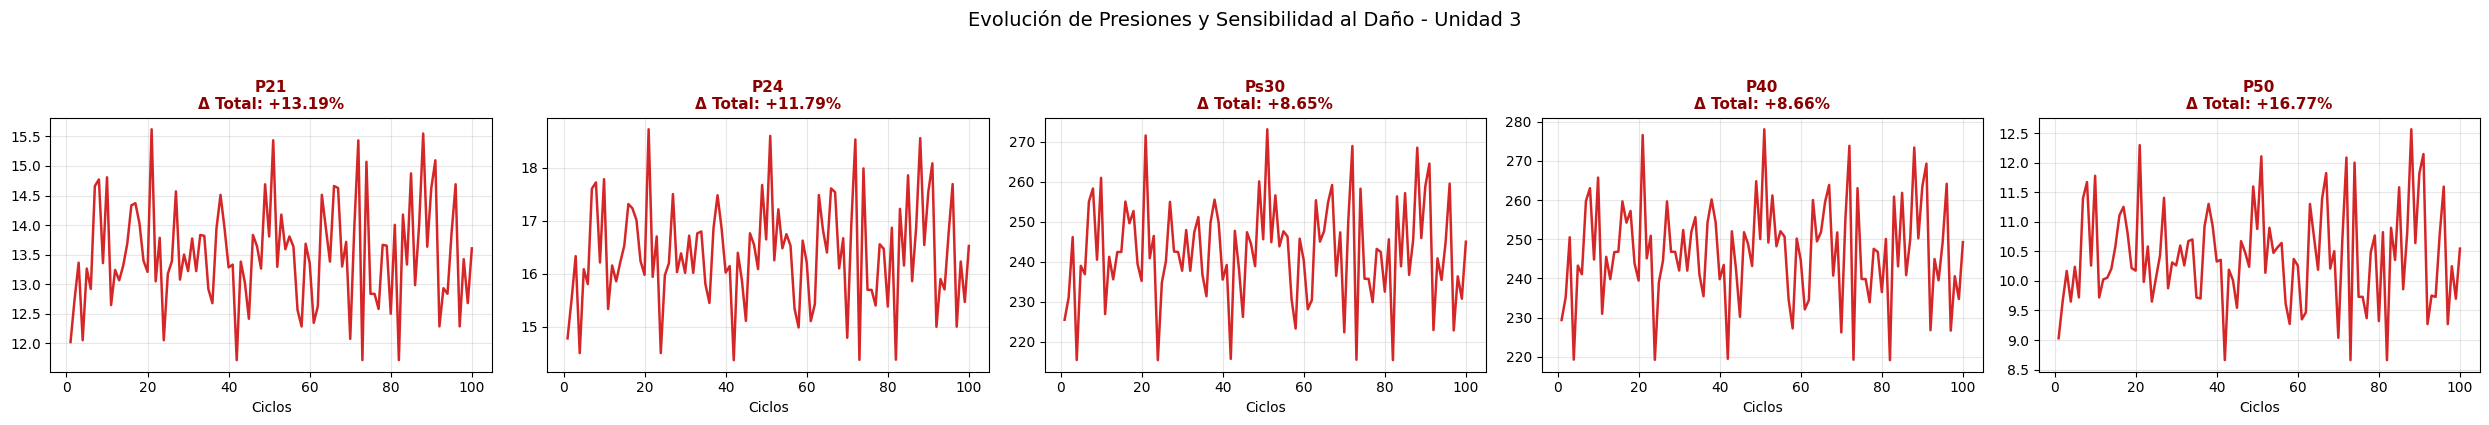

In [23]:
# Lista actualizada con el nombre correcto ps30 y otras comunes
presiones_buscadas = ['P21', 'P24', 'Ps30', 'P40', 'P50']
unidades = [2, 3]

with h5py.File(filename, 'r') as hdf:
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    A_dev = hdf.get('A_dev')[:]
    
    presiones_validas = [p for p in presiones_buscadas if p in sensor_names]
    print(f"Sensores detectados: {presiones_validas}")

    for uid in unidades:
        mask = A_dev[:, 0] == uid
        cycles = A_dev[mask, 1]
        
        n_p = len(presiones_validas)
        fig, axes = plt.subplots(1, n_p, figsize=(5 * n_p, 4), sharex=True)
        if n_p == 1: axes = [axes]

        for j, p_name in enumerate(presiones_validas):
            idx = np.where(sensor_names == p_name)[0][0]
            data = hdf.get('X_s_dev')[mask, idx]
            
            df_avg = pd.DataFrame({'c': cycles, 'v': data}).groupby('c').mean()
            
            # Cálculo del Cambio Total
            val_inicial = df_avg['v'].iloc[0]
            val_final = df_avg['v'].iloc[-1]
            cambio_total = ((val_final - val_inicial) / val_inicial) * 100
            
            # Color dinámico: rojo si sube, azul si baja
            color_linea = 'tab:red' if abs(cambio_total) > 1 else 'tab:blue'
            
            axes[j].plot(df_avg.index, df_avg['v'], color=color_linea, linewidth=1.8)
            
            # Formatear el título con el Delta %
            axes[j].set_title(f'{p_name}\nΔ Total: {cambio_total:+.2f}%', 
                              fontsize=11, fontweight='bold', color='darkred' if abs(cambio_total) > 1 else 'black')
            
            axes[j].set_xlabel('Ciclos')
            axes[j].grid(True, alpha=0.3)
            
        plt.suptitle(f'Evolución de Presiones y Sensibilidad al Daño - Unidad {uid}', fontsize=14, y=1.05)
        plt.tight_layout()
        plt.show()

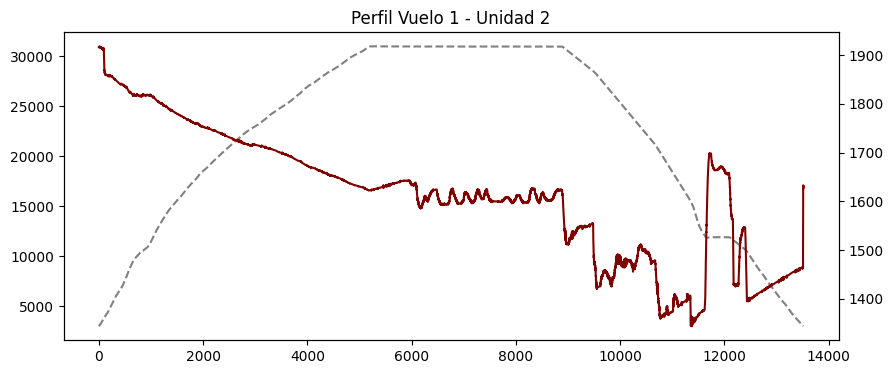

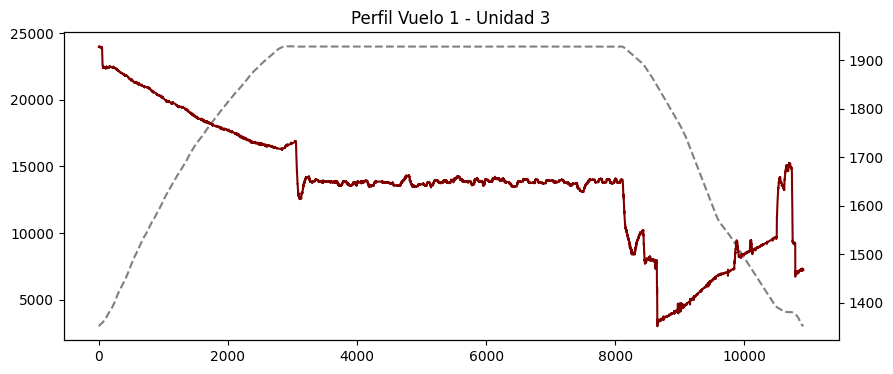

In [24]:
with h5py.File(filename, 'r') as hdf:
    w_names = np.array(hdf.get('W_var')).astype(str)
    alt_idx = np.where(w_names == 'alt')[0][0]
    t48_idx = np.where(sensor_names == 'T48')[0][0]
    
    for uid in unidades:
        mask_v1 = (A_dev[:, 0] == uid) & (A_dev[:, 1] == 1)
        alt = hdf.get('W_dev')[mask_v1, alt_idx]
        t48 = hdf.get('X_s_dev')[mask_v1, t48_idx]
        
        fig, ax1 = plt.subplots(figsize=(10, 4))
        ax1.plot(alt, color='gray', linestyle='--', label='Altitud')
        ax2 = ax1.twinx()
        ax2.plot(t48, color='maroon', label='T48')
        plt.title(f'Perfil Vuelo 1 - Unidad {uid}')
        plt.show()

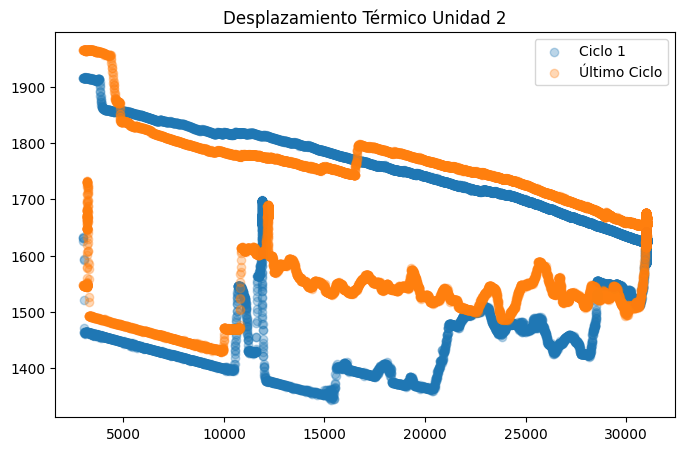

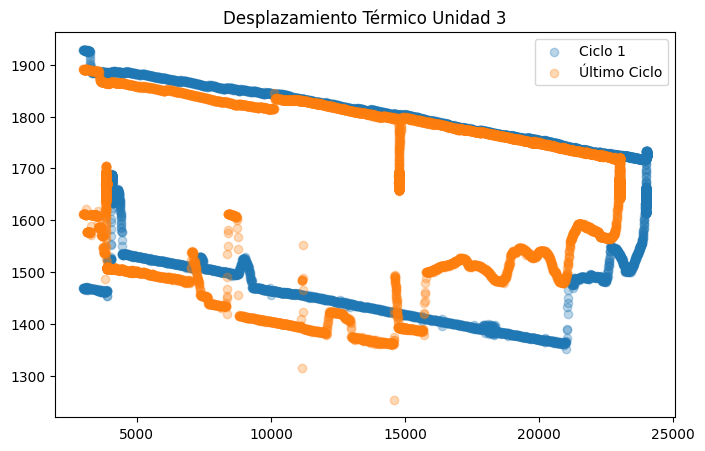

In [25]:
with h5py.File(filename, 'r') as hdf:
    for uid in unidades:
        mask_u = A_dev[:, 0] == uid
        vuelos = np.unique(A_dev[mask_u, 1])
        
        v_ini, v_fin = vuelos[0], vuelos[-1]
        
        m_ini = (A_dev[:, 0] == uid) & (A_dev[:, 1] == v_ini)
        m_fin = (A_dev[:, 0] == uid) & (A_dev[:, 1] == v_fin)
        
        plt.figure(figsize=(8, 5))
        plt.scatter(hdf.get('W_dev')[m_ini, alt_idx], hdf.get('X_s_dev')[m_ini, t48_idx], alpha=0.3, label='Ciclo 1')
        plt.scatter(hdf.get('W_dev')[m_fin, alt_idx], hdf.get('X_s_dev')[m_fin, t48_idx], alpha=0.3, label='Último Ciclo')
        plt.title(f'Desplazamiento Térmico Unidad {uid}')
        plt.legend()
        plt.show()

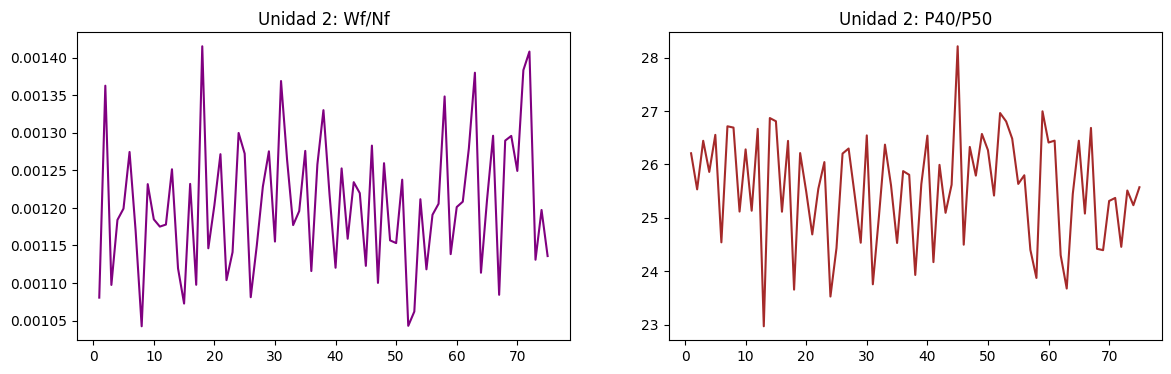

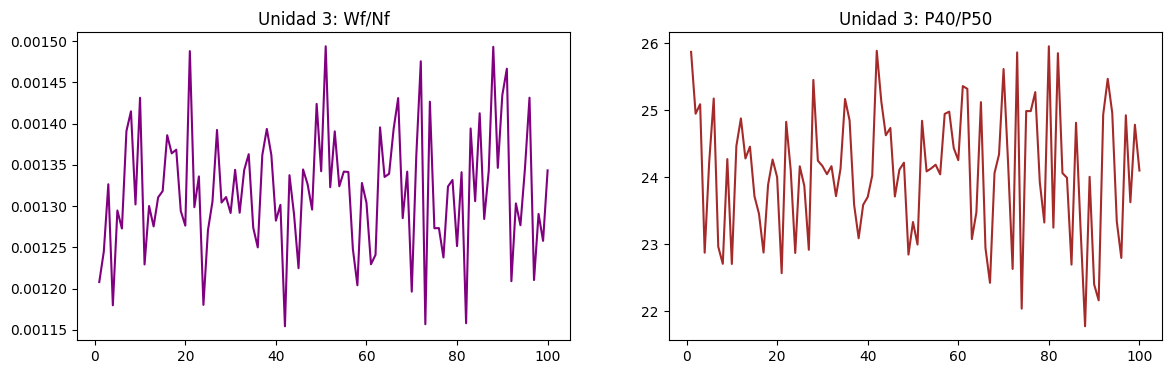

In [26]:
with h5py.File(filename, 'r') as hdf:
    nf_idx = np.where(sensor_names == 'Nf')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    p40_idx = np.where(sensor_names == 'P40')[0][0]
    p50_idx = np.where(sensor_names == 'P50')[0][0]
    
    for uid in unidades:
        mask = A_dev[:, 0] == uid
        c = A_dev[mask, 1]
        
        wf_nf = hdf.get('X_s_dev')[mask, wf_idx] / hdf.get('X_s_dev')[mask, nf_idx]
        p40_p50 = hdf.get('X_s_dev')[mask, p40_idx] / hdf.get('X_s_dev')[mask, p50_idx]
        
        df_r = pd.DataFrame({'c': c, 'wf_nf': wf_nf, 'p40_p50': p40_p50}).groupby('c').mean()
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        ax1.plot(df_r.index, df_r['wf_nf'], color='purple')
        ax1.set_title(f'Unidad {uid}: Wf/Nf')
        ax2.plot(df_r.index, df_r['p40_p50'], color='brown')
        ax2.set_title(f'Unidad {uid}: P40/P50')
        plt.show()

La razón por la cual en las unidades 2 y 3 ves que todas las presiones suben, a diferencia de la unidad 1, no es porque la física del motor haya cambiado, sino por **el perfil de la misión**.

1. El efecto de la Altitud y el Mach (Condiciones de Operación)La Unidad 1 tiene vuelos cortos (clase 1), lo que significa que pasa mucho tiempo a bajas altitudes y en ciclos de despegue/aterrizaje. Las unidades 2 y 3 (vuelos largos) operan gran parte del tiempo en crucero a gran altitud.
    * En la Unidad 1: Las condiciones ambientales son más uniformes, por lo que la caída de $P_{s30}$ y $P_{40}$ por ineficiencia de la turbina es más "visible".
    * En las Unidades 2 y 3: Al final de la vida útil del motor, es muy probable que para compensar la degradación, el sistema de control esté operando el motor a regímenes de RPM más altos o en puntos de la envolvente de vuelo donde la presión de entrada es mayor para mantener el empuje.
2. El "Bias" del Control de EmpujeRecuerda que el FADEC (el cerebro del motor) tiene una prioridad: Mantener el empuje solicitado.
    * Si la turbina de alta (HPT) está muy degradada, el motor necesita mover mucho más aire y quemar más combustible para generar la misma fuerza.
    * En misiones largas, para compensar la pérdida de eficiencia, el motor aumenta la velocidad de los ejes ($N_1$ y $N_2$). Al girar más rápido, los compresores (LPC y HPC) elevan la presión de todo el sistema por encima de los valores "normales" de un motor nuevo, tratando de compensar que la turbina no está extrayendo trabajo correctamente.
3. Acumulación de Calor y PresiónComo viste que el combustible ($W_f$) sube, esto inyecta muchísima energía térmica. En un sistema cerrado de alta velocidad:
    * Más combustible = Gases más calientes = Gases con mayor volumen específico.
    * Si el volumen de gas aumenta y el motor está tratando de forzar ese gas a través de las mismas toberas, la presión en todo el núcleo tiende a subir por un efecto de "atascamiento" o bloqueo aerodinámico.

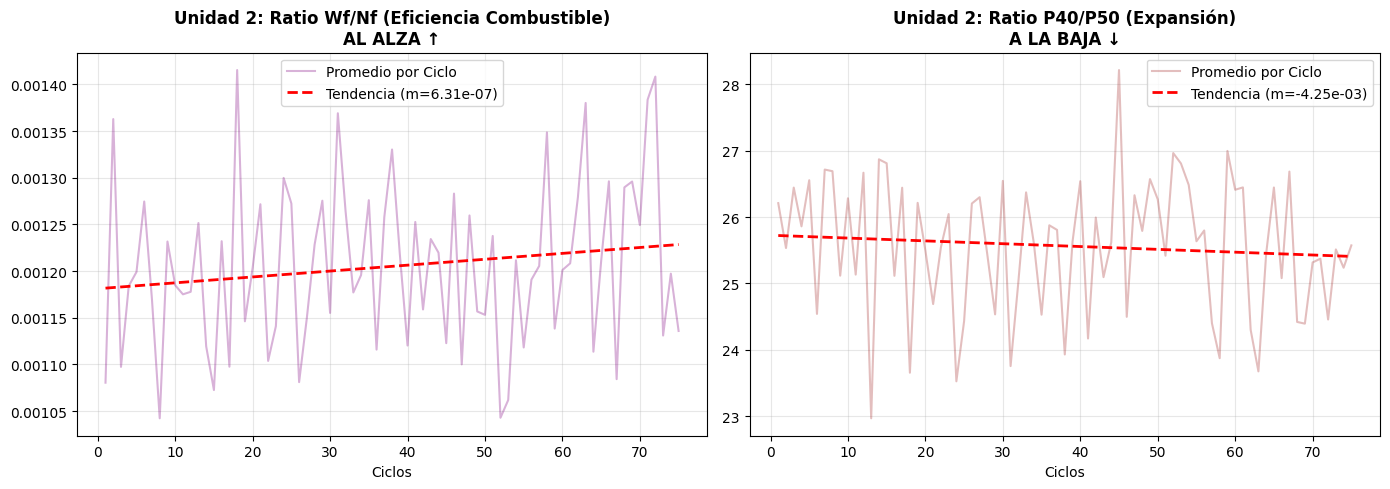

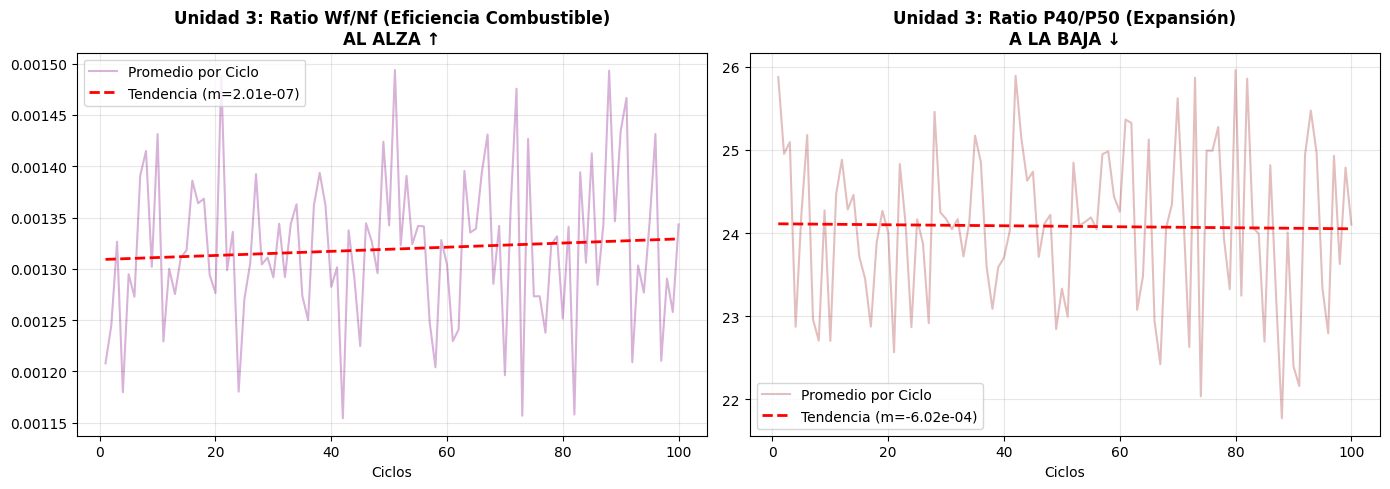

In [27]:
with h5py.File(filename, 'r') as hdf:
    # 1. Recuperar nombres de variables e índices
    sensor_names = np.array(hdf.get('X_s_var')).astype(str)
    A_dev = hdf.get('A_dev')[:]
    
    # Verificamos nombres exactos (ps30 vs p30)
    nf_idx = np.where(sensor_names == 'Nf')[0][0]
    wf_idx = np.where(sensor_names == 'Wf')[0][0]
    p50_idx = np.where(sensor_names == 'P50')[0][0]
    
    # Manejador de error para P40/ps30
    p_in_name = 'P40' if 'P40' in sensor_names else 'ps30'
    p_in_idx = np.where(sensor_names == p_in_name)[0][0]
    
    for uid in unidades:
        mask = A_dev[:, 0] == uid
        c = A_dev[mask, 1]
        
        # 2. Extraer datos con el archivo abierto
        wf_data = hdf.get('X_s_dev')[mask, wf_idx]
        nf_data = hdf.get('X_s_dev')[mask, nf_idx]
        pin_data = hdf.get('X_s_dev')[mask, p_in_idx]
        p50_data = hdf.get('X_s_dev')[mask, p50_idx]
        
        # 3. Calcular ratios
        wf_nf = wf_data / nf_data
        p_ratio = pin_data / p50_data
        
        # 4. Consolidar por ciclo
        df_r = pd.DataFrame({'c': c, 'wf_nf': wf_nf, 'p_ratio': p_ratio}).groupby('c').mean()
        
        # 5. Graficar
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        ratios_config = [
            ('wf_nf', ax1, 'purple', 'Ratio Wf/Nf (Eficiencia Combustible)'), 
            ('p_ratio', ax2, 'brown', f'Ratio {p_in_name}/P50 (Expansión)')
        ]

        for col, ax, color, title in ratios_config:
            x = df_r.index.values
            y = df_r[col].values
            
            # Datos reales
            ax.plot(x, y, color=color, alpha=0.3, label='Promedio por Ciclo')
            
            # Línea de tendencia
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            ax.plot(x, p(x), "r--", linewidth=2, label=f'Tendencia (m={z[0]:.2e})')
            
            # Etiqueta de dirección
            direccion = "AL ALZA ↑" if z[0] > 0 else "A LA BAJA ↓"
            ax.set_title(f'Unidad {uid}: {title}\n{direccion}', fontweight='bold')
            ax.set_xlabel('Ciclos')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

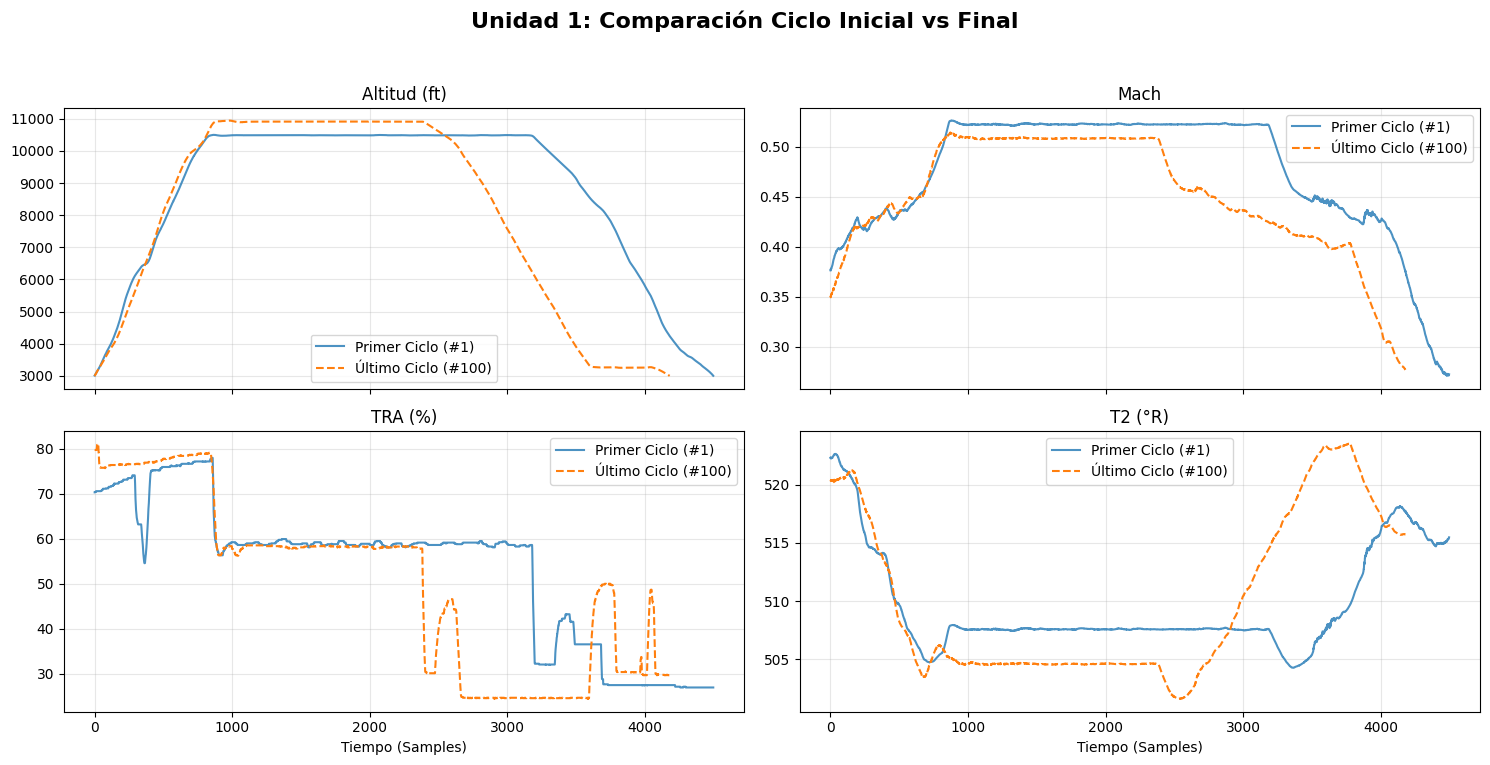

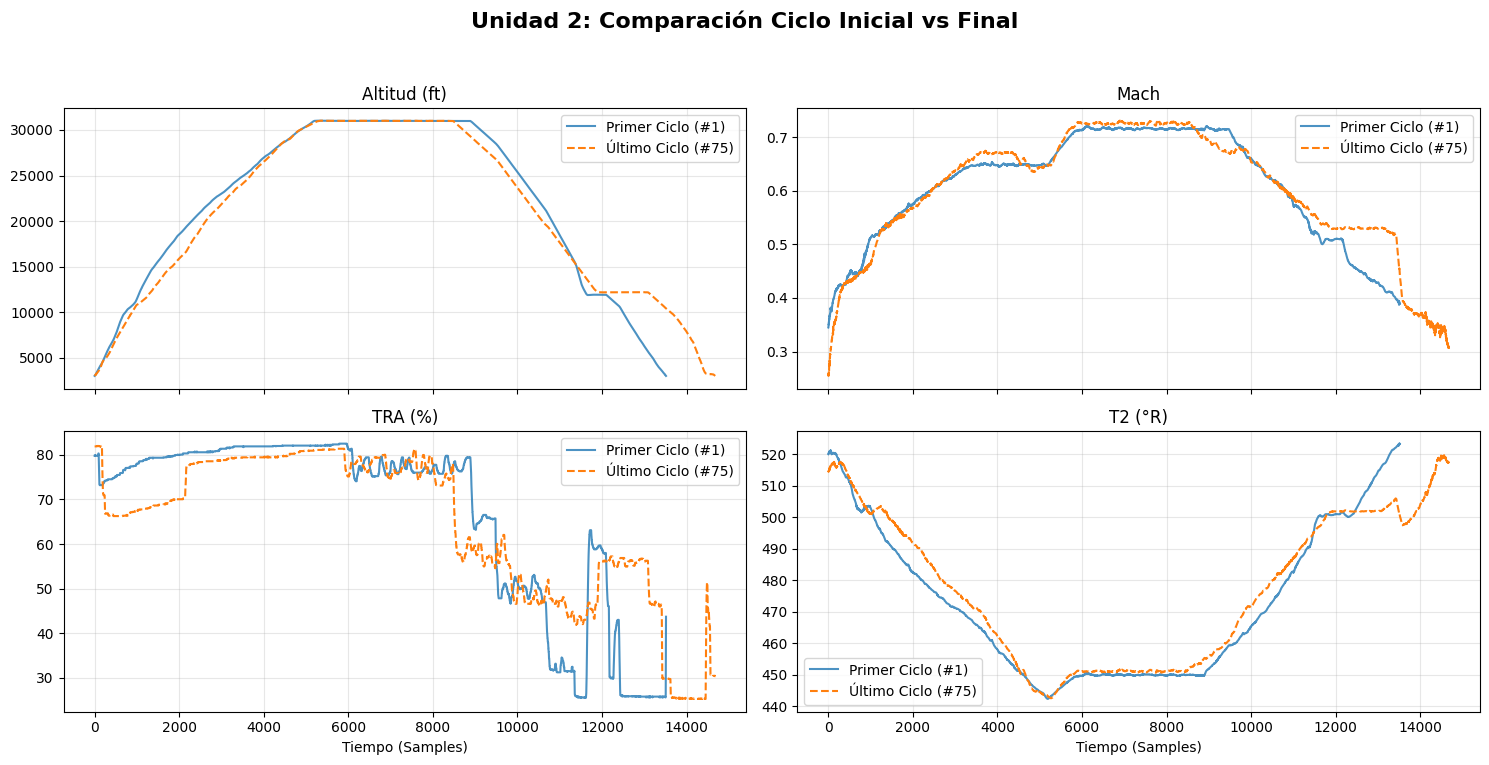

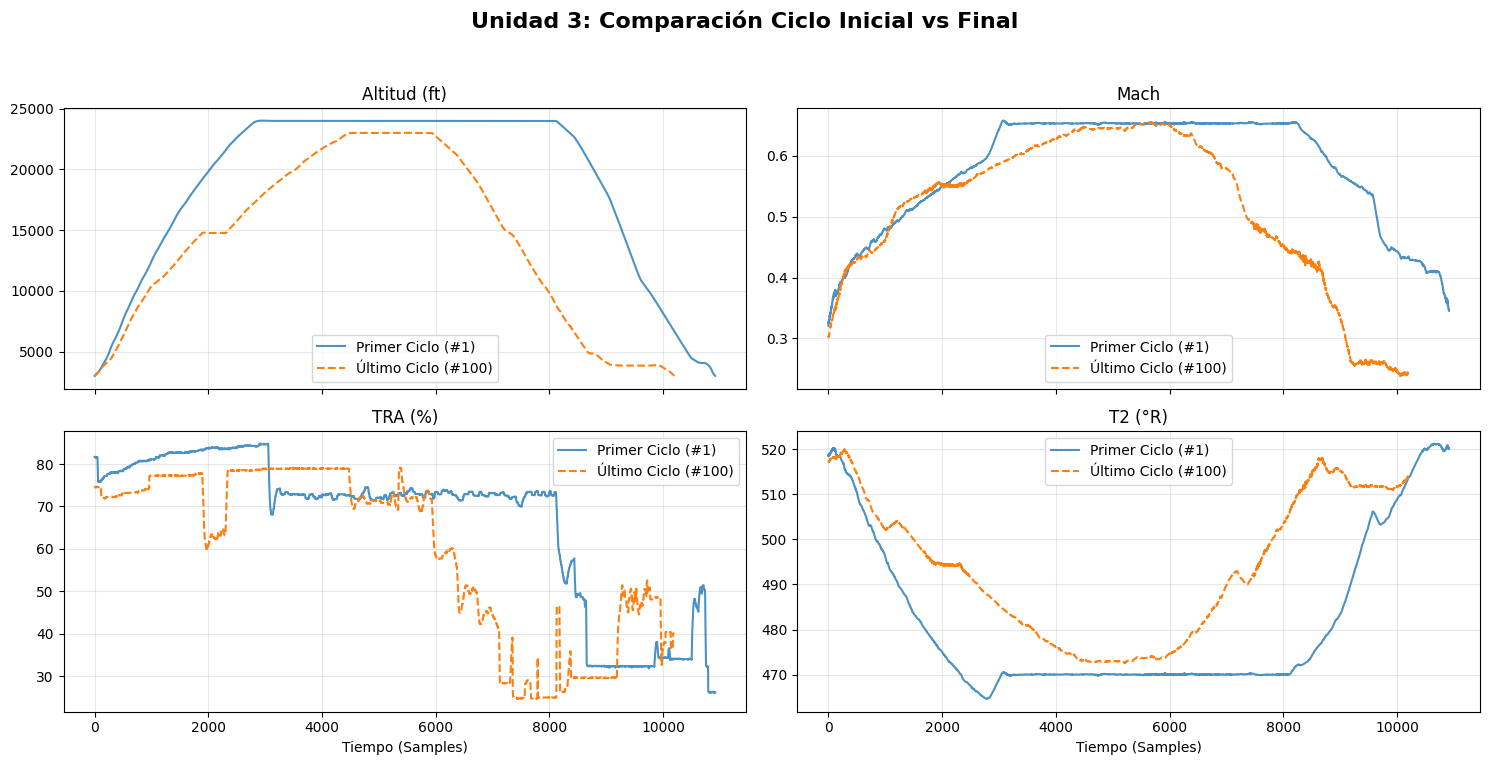

In [28]:
# Supongamos que ya tienes cargados: 
# W_dev (condiciones operativas) y A_dev (auxiliar: [unit, cycle, ...])

unidades_a_graficar = [1, 2, 3]
variables_w = ['Altitud (ft)', 'Mach', 'TRA (%)', 'T2 (°R)']

for unit in unidades_a_graficar:
    # 1. Filtrar datos de la unidad
    mask_unit = A_dev[:, 0] == unit
    w_unit = W_dev[mask_unit]
    a_unit = A_dev[mask_unit]
    
    # 2. Identificar primer y último ciclo
    ciclos = np.unique(a_unit[:, 1])
    primer_ciclo = ciclos[0]
    ultimo_ciclo = ciclos[-1]
    
    # 3. Crear la figura
    fig, axs = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
    fig.suptitle(f'Unidad {int(unit)}: Comparación Ciclo Inicial vs Final', fontsize=16, fontweight='bold')
    
    for i, var_name in enumerate(variables_w):
        ax = axs[i//2, i%2]
        
        # Datos ciclo inicial
        mask_inicio = a_unit[:, 1] == primer_ciclo
        ax.plot(w_unit[mask_inicio, i], label=f'Primer Ciclo (#{int(primer_ciclo)})', alpha=0.8)
        
        # Datos ciclo final
        mask_final = a_unit[:, 1] == ultimo_ciclo
        ax.plot(w_unit[mask_final, i], label=f'Último Ciclo (#{int(ultimo_ciclo)})', linestyle='--')
        
        ax.set_title(var_name)
        ax.legend()
        ax.grid(True, alpha=0.3)
        if i >= 2: ax.set_xlabel('Tiempo (Samples)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

En estas gráficas verás claramente las fases del vuelo. El N-CMAPSS es famoso porque, a diferencia del CMAPSS original, incluye perfiles de vuelo reales.

* Ascenso: Verás que la Altitud y el Mach suben rápidamente.

* Crucero: Verás una meseta (plateau) donde la altitud se mantiene constante (ej. 35,000 ft).

* Descenso: Una caída gradual hasta llegar a cero.

¿Qué buscar? Compara si el último ciclo de la unidad 3 es más corto o más errático que el primero. A veces, las unidades que fallan prematuramente han tenido misiones con perfiles de altitud más exigentes (más cambios de nivel).

<div class="alert alert-block alert-success">
Si en el último ciclo ves que para un mismo nivel de Mach y Altitud, las temperaturas internas (que veremos después en $X_s$) son más altas, significa que el motor está perdiendo eficiencia y necesita "esforzarse" más para cumplir la misma misión. Deberías notar que cuando la Altitud sube, la $T2$ baja drásticamente (pasa de unos 518 °R a nivel del mar a mucho menos en crucero).

<div class="alert alert-block alert-info">
TRA (Ángulo de la palanca de gases): Es la "demanda" del piloto. Durante el despegue verás un pico máximo.